# TrustRegionRadius.jl — a guided tour

The package separates four orthogonal axes: the **radius rule**, the **model
Hessian**, the **subproblem solver** and the **sampling rule**. Most of what it is
for is measuring what happens when you vary one and hold the rest fixed.

| part | subject |
|:--|:--|
| 0 | Setup: the environment, and what is optional |
| 1 | Radius update rules, and the `SecondOrder` wrapper |
| 2 | Declaring models: `ADNLPModels`, `ADNLSModel`, CUTEst |
| 3 | Running a solve and reading the output |
| 4 | Deterministic problems |
| 5 | Finite sums |
| 6 | Expectations, and the ten sampling rules |
| 7 | `LogisticRegression` |
| 8 | `LeastSquares` |

Every cell asserts what it claims with a real `@test`, so running this notebook top
to bottom is a smoke test of the package as well as a tour of it. Nothing prints
without also being checked.

---
## Part 0 — Setup

Run this notebook against `notebooks/Project.toml`. From the repository root:

```
julia --project=notebooks -e 'using Pkg; Pkg.develop(path="."); Pkg.instantiate()'
```

**Required**: `TrustRegionRadius`, `ADNLPModels`, `NLPModels`, `SolverCore` and the
standard library. **Optional**: `Plots`, used for two figures, and `CUTEst`, used in
Part 2 only. Neither is needed for anything else, and Part 2 says how to skip CUTEst.

Two problems are declared here because every later part uses them. Part 2 explains
what `ADNLPModel` is doing and how else to build one.

In [1]:
using TrustRegionRadius
using ADNLPModels, NLPModels, SolverCore
using LinearAlgebra, Random, Statistics, Printf
using Plots
using Test

Random.seed!(0)

# Rosenbrock: the curved-valley case used throughout.
rosen(x) = (1 - x[1])^2 + 100 * (x[2] - x[1]^2)^2
nlp = ADNLPModel(rosen, [-1.2, 1.0], name = "Rosenbrock")
x = nlp.meta.x0
g = grad(nlp, x)

# A saddle, for the second-order material: ∇²f(0) = diag(-1, 1).
saddle(v) = v[1]^4/4 - v[1]^2/2 + v[2]^2/2
sp = ADNLPModel(saddle, [0.0, 0.0], name = "saddle")


# The saddle's leftmost eigenvalue, used by Part 1. Exactly -1 by construction.
λ_exact = lambda_min_estimate(ExactHessian(), sp, [0.0, 0.0])
@test λ_exact ≈ -1.0 rtol = 1e-10

@test nlp.meta.nvar == 2
@test obj(nlp, x) ≈ 24.2
@printf("Julia %s
", VERSION)
@printf("f(x0) = %.4f,  ‖g(x0)‖ = %.4f
", obj(nlp, x), norm(g))

Julia 1.11.0


f(x0) = 24.2000,  ‖g(x0)‖ = 232.8677


---
## Part 1 — Radius update rules

The radius rule decides `Δ_{k+1}` from `Δ_k`, the ratio `ρ_k`, the step length
`‖s_k‖`, and the criticality measure. The signature is uniform across every rule:

```julia
update_radius!(rule, Δ, ρ, accepted, η1, η2, s_norm, crit_old, crit_new)
```

### Acceptance is decoupled from scaling

`η` decides whether the step is **taken**. `η1` and `η2` decide only how the
radius is **scaled**, and the rule never sees `η`. With `η < η1` there is a middle
band `ρ ∈ [η, η1)` in which the step is accepted *and* the radius contracts — a
combination the classical coupled formulation cannot express.

`η` defaults to `η1`, reproducing the classical algorithm exactly.

In [2]:
p_coupled   = TRParams(η1 = 0.1, η2 = 0.9)                 # η defaults to η1
p_decoupled = TRParams(η = 0.0, η1 = 0.25, η2 = 0.75)

@test p_coupled.η == p_coupled.η1 == 0.1
@test p_decoupled.η < p_decoupled.η1 < p_decoupled.η2

# The chain 0 ≤ η ≤ η1 ≤ η2 < 1 is enforced at construction.
@test_throws ArgumentError TRParams(η = 0.5, η1 = 0.2, η2 = 0.9)
@test_throws ArgumentError TRParams(η1 = 0.9, η2 = 0.2)

# Both spellings of the keywords work; ASCII is primary.
@test TRParams(η₁ = 0.2).η1 == 0.2 == TRParams(η1 = 0.2).η₁



Test Passed

### The three asymptotic regimes

`asymptotic_regime(rule)` is the classification the whole survey turns on:

| regime | meaning | rules |
|:--|:--|:--|
| `:bounded_below` | `liminf Δ_k > 0` | `RDelta` |
| `:step_summable` | `Σ_k Δ_k < ∞` locally | `RStep`, `RAdaptiveStep`, `RRTR` |
| `:vanishing` | `Δ_k → 0`, tied to criticality | `RDFO`, `RGrad`, `RGradCapped`, `RAdaptiveGrad`, `RAdaptiveFanYuan`, `RRTRGrad` |

The two-way predicate `is_criticality_anchored` cannot express the middle one,
which is why both exist.

In [3]:
RULES = [RDelta(), RStep(), RDFO(), RGrad(), RGradCapped(),
         RAdaptiveStep(), RAdaptiveGrad(), 
         RRTR(), RRTRGrad()]

for r in RULES
    reg = asymptotic_regime(r)
    @test reg in (:vanishing, :step_summable, :bounded_below)
    is_criticality_anchored(r) && @test reg === :vanishing
    @printf("%-18s %-16s anchored=%-5s retrospective=%s\n",
            nameof(typeof(r)), reg, is_criticality_anchored(r), needs_retrospective(r))
end

RDelta             bounded_below    anchored=false retrospective=false
RStep              step_summable    anchored=false retrospective=false
RDFO               vanishing        anchored=true  retrospective=false
RGrad              vanishing        anchored=true  retrospective=false
RGradCapped        vanishing        anchored=true  retrospective=false
RAdaptiveStep      step_summable    anchored=false retrospective=false
RAdaptiveGrad      vanishing        anchored=true  retrospective=false
RRTR               step_summable    anchored=false retrospective=true
RRTRGrad           vanishing        anchored=true  retrospective=true


### The invariant every rule must satisfy

**On an unsuccessful iteration the radius must strictly contract.** A rejected step
leaves the model *and* the iterate unchanged, so a rule that returns `Δ_{k+1} = Δ_k`
there re-solves an identical subproblem for ever.

This is the test the retrospective rules once failed, when a classical `ρ` was
compared against retrospective thresholds `η̃₁`.

In [4]:
η, η1, η2 = 0.1, 0.25, 0.75
Δ, s_norm, crit = 1.0, 0.8, 2.0

for r in RULES
    reset_rule!(r)
    Δ0 = initial_radius(r, Δ, crit)          # μ-based rules start from μ0·crit
    for ρ in (-Inf, -1.0, 0.0, 0.05, 0.099)  # every ρ strictly below η
        rr = deepcopy(r); reset_rule!(rr)
        Δ1 = update_radius!(rr, Δ0, ρ, false, η1, η2, s_norm, crit, crit)
        @test Δ1 < Δ0 && Δ1 > 0 && isfinite(Δ1)
    end
end
println("all $(length(RULES)) rules contract on rejection ✓")

all 9 rules contract on rejection ✓


In [5]:
# Two rules in detail.

# RDelta: three constants, read off ρ alone. Criticality-blind.
r = RDelta(γ1 = 0.25, γ2 = 0.5, γ3 = 2.0)
@test update_radius!(r, 1.0, 0.05, false, 0.2, 0.9, 1.0, 1.0, 1.0) == 0.25  # γ1
@test update_radius!(r, 1.0, 0.50, true,  0.2, 0.9, 1.0, 1.0, 1.0) == 0.50  # γ2
@test update_radius!(r, 1.0, 0.95, true,  0.2, 0.9, 1.0, 1.0, 1.0) == 2.00  # γ3

# RGrad: Δ = μ‖g‖, so μ *is* the radius-to-criticality ratio Δ/‖g‖. It searches
# for the inactivity threshold κ̄ = 4/λ*_min without knowing it, and because μ is
# uncapped it crosses any threshold eventually.
r = RGrad(μ = 1.0, γ1 = 0.25, γ2 = 0.5, γ3 = 2.0)
@test initial_radius(r, 99.0, 3.0) == 3.0          # Δ0 is ignored entirely
Δ = update_radius!(r, 1.0, 0.95, true, 0.2, 0.9, 0.9, 1.0, 2.0)
@test r.μ == 2.0 && Δ == 4.0                       # μ ← γ3μ, then Δ = μ‖g_{k+1}‖

# The ½Δ guard: expansion only when the step actually used the region.
r = RGrad(μ = 1.0, γ3 = 2.0)
update_radius!(r, 1.0, 0.95, true, 0.2, 0.9, 0.4, 1.0, 1.0);  @test r.μ == 1.0
update_radius!(r, 1.0, 0.95, true, 0.2, 0.9, 0.6, 1.0, 1.0);  @test r.μ == 2.0
println("RDelta and RGrad behave as advertised ✓")

RDelta and RGrad behave as advertised ✓


### Running the solver, and reading the trace

`trace = true` records per-iteration trajectories under `stats.solver_specific`.
Two of them are worth collecting even when nothing else is:

- `:active_trajectory` — did the constraint bind? This is what separates
  mechanisms whose first-order behaviour is identical.
- `:accepted_trajectory` — cannot be reconstructed from `:ratio_trajectory` once
  `η < η1`, because the rule's thresholds no longer coincide with the one that
  decided the step.

In [6]:
params = TRParams(tol = 1e-8, max_iterations = 5_000)
results = Dict{String, Any}()

for r in (RDelta(), RStep(), RDFO(ζ = 1.0), RGrad(), RAdaptiveGrad(), RRTR())
    prob = ADNLPModel(rosen, [-1.2, 1.0])
    st = tr_solve(prob; rule = r, model = ExactHessian(),
                  subsolver = SteihaugCG(), params = params, trace = true)
    @test st.status === :first_order
    results[string(nameof(typeof(r)))] = st
end

@printf("%-18s %6s %10s %12s %10s\n", "rule", "iters", "‖g‖", "final Δ", "active %")
for (name, st) in sort(collect(results); by = first)
    ss = st.solver_specific
    @printf("%-18s %6d %10.2e %12.2e %9.0f%%\n", name, st.iter, st.dual_feas,
            ss[:final_delta], 100 * mean(ss[:active_trajectory]))
end

rule                iters        ‖g‖      final Δ   active %
RAdaptiveGrad          41   6.08e-10     5.11e-06        34%


RDFO                   37   9.65e-10     1.56e-02        43%
RDelta                 32   9.65e-10     4.00e+00        44%
RGrad                  37   0.00e+00     0.00e+00        38%
RRTR                   38   3.17e-09     1.26e-01        53%
RStep                  43   0.00e+00     2.54e-09        65%


In [7]:
# The regime classification is observable on the run, not just declared.
Δ_blind    = results["RDelta"].solver_specific[:delta_trajectory]
Δ_anchored = results["RGrad"].solver_specific[:delta_trajectory]

@test Δ_blind[end]    > 1e-3      # liminf Δ_k > 0
@test Δ_anchored[end] < 1e-3      # Δ_k → 0 with ‖g_k‖
@printf("final Δ:  RDelta = %.3e (bounded below)   RGrad = %.3e (vanishing)\n",
        Δ_blind[end], Δ_anchored[end])

# Trajectory alignment: Δ, ‖g‖ and f have a value *before* the first iteration.
st = results["RDelta"]; ss = st.solver_specific
for k in (:delta_trajectory, :grad_trajectory, :obj_trajectory)
    @test length(ss[k]) == st.iter + 1
end
for k in (:ratio_trajectory, :step_trajectory, :active_trajectory,
          :accepted_trajectory)
    @test length(ss[k]) == st.iter
end

# Acceptance follows ρ ≥ η and nothing else.
@test ss[:accepted_trajectory] == [ρ >= params.η for ρ in ss[:ratio_trajectory]]
println("trace shapes and acceptance semantics ✓")

final Δ:  RDelta = 4.000e+00 (bounded below)   RGrad = 0.000e+00 (vanishing)
trace shapes and acceptance semantics ✓


---
### The `SecondOrder` wrapper

At a first-order critical point that is **not** a minimiser, `‖g‖ = 0` while
`λ_min(B) < 0`. A rule anchored to `‖g‖` therefore reports the radius it would use
at a solution, and the two anchored families fail differently:

- `RGrad(‖g‖)` sets `Δ = μ·0 = 0` and **halts outright**;
- `RDFO(‖g‖)` finds `Δ > ζ·0` at every iteration and **contracts to the floor**.

The repair is to replace `‖g‖` by

$$\tau(x) = \max\{\,\|g(x)\|,\ -\lambda_{\min}(B(x))\,\}$$

which vanishes exactly at a second-order critical point of the model. `SecondOrder`
is a **wrapper**, not a new family: it forwards `update_radius!` unchanged and
overrides only `criticality`.

In [8]:
@test tau_criticality(3.0,  5.0) == 3.0     # positive curvature never enlarges τ
@test tau_criticality(3.0, -5.0) == 5.0     # curvature dominates
@test tau_criticality(0.0, -2.0) == 2.0     # the saddle: τ > 0 = ‖g‖
@test tau_criticality(0.0,  2.0) == 0.0     # a genuine minimiser

# The wrapper only changes the measure.
inner = RGrad(μ = 2.0)
wrapped = SecondOrder(inner)
@test criticality(wrapped, 1.0, -4.0) == 4.0
@test criticality(inner,   1.0, -4.0) == 1.0
@test wrapped.μ == 2.0                       # fields forward
@test needs_curvature(wrapped) && !needs_curvature(inner)

# Only rules that read the criticality slot may be wrapped — otherwise it would
# be a silent no-op.
@test_throws ArgumentError SecondOrder(RDelta())
@test_throws ArgumentError SecondOrder(RStep())
println("τ and the SecondOrder wrapper ✓")

τ and the SecondOrder wrapper ✓


In [9]:
# The failure, made explicit. λ = −1, ‖g‖ = 0: the exact saddle.
λ, gn = -1.0, 0.0

@test criticality(RGrad(), gn, λ) == 0.0 ; # is 1st order so only uses ‖g‖, which is 0
@test criticality(RGradTau(), gn, λ) == 1.0 ; # is 2nd order so uses τ = max(‖g‖, −1/λ) = 1.0

### The two methods a rule must supply

```julia 
initial_radius(rule, Δ0, g_norm) 
```

For 1st-order rules, `g_norm` is `‖g‖`. 
```julia
update_radius!(rule, Δ, ρ, accepted, η1, η2, s_norm, g_norm_old, g_norm_new)   
```

For second-order rules, it is `τ`. The `SecondOrder` wrapper is what makes the rule see `τ` instead of `‖g‖`.
```julia 
update_radius!(rule, Δ, ρ, accepted, η1, η2, s_norm, crit_old, crit_new)   
```


In [10]:
# The same saddle, one step further on: what the two rules do with the radius.
λ, gn = -1.0, 0.0
rho, accepted, η1, η2 = 0.95, true, 0.1, 0.9

@test initial_radius(RGrad(μ = 1.0), 1.0, criticality(RGrad(), gn, λ)) == 0.0     # dead
@test initial_radius(RGradTau(μ = 1.0), 1.0, criticality(RGradTau(), gn, λ)) == 1.0

Test Passed

initial Δ = 1.000e+00, 


after 40 iterations at the saddle: Δ = 9.095e-13, 


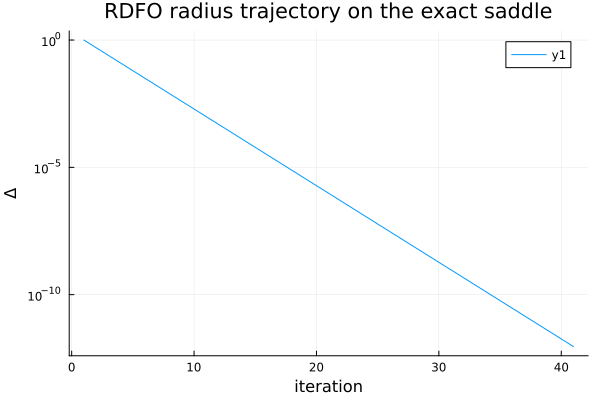

In [11]:
rd = RDFO(ζ = 1.0, γ2 = 0.5, γ3 = 3.0)

old_criticality = criticality(rd, gn, λ)
new_criticality = criticality(rd, gn, λ)

Δ = 1.0
@printf("initial Δ = %.3e, \n",
        Δ)
Δ_traj = Float64[Δ]
for _ in 1:40
    Δ  = update_radius!(rd,  Δ,  0.95, true, 0.1, 0.9, Δ,  gn, criticality(rd,  gn, λ))
    push!(Δ_traj, Δ)
end

@printf("after 40 iterations at the saddle: Δ = %.3e, \n",
        Δ)

@test Δ  < 1e-10      # collapsed to the floor

plot(Δ_traj, yscale = :log10, xlabel = "iteration", ylabel = "Δ",
     title = "RDFO radius trajectory on the exact saddle")
     


Δτ = 1.000e+00
after 40 iterations at the saddle: Δτ = 2.566e+00


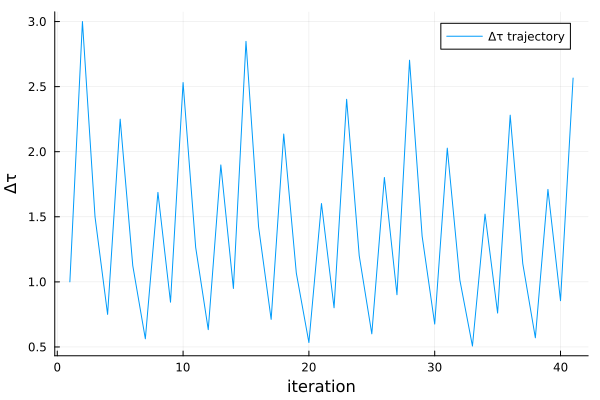

In [12]:

rdτ =  RDFOTau(ζ = 1.0, γ2 = 0.5, γ3 = 3.0)

old_criticality = criticality(rdτ, gn, λ)
new_criticality = criticality(rdτ, gn, λ)

@test old_criticality == new_criticality == 1.0

Δτ = 1.0
Δτ_traj = [Δτ]
@printf("Δτ = %.3e\n", Δτ)
for _ in 1:40
    Δτ = update_radius!(rdτ, Δτ, rho, accepted, η1, η2, Δτ, old_criticality, new_criticality)
    push!(Δτ_traj, Δτ)
end
@printf("after 40 iterations at the saddle: Δτ = %.3e\n", Δτ)

@test Δτ >= 0.5       # held at the scale of the curvature that is available: can never decrease below ½Δτ = 0.5

plot(Δτ_traj,  label = "Δτ trajectory", xlabel = "iteration", ylabel = "Δτ")

### τ-anchoring is only half of it

Keeping the radius **positive** near a saddle does not make the step **go
anywhere**. Steihaug CG stops at the first direction of negative curvature it
happens to reach, and the decrease it guarantees carries no `|λ_min|Δ²` term.

`EigenPoint` wraps a subsolver so the returned step always achieves at least the
decrease available along the leftmost eigenvector. Both halves are needed.

!!! warning

**Steihaug CG is not guaranteed to find a direction of negative curvature**, and if
it does find one, it is not guaranteed to satisfy the sufficient eigen-decrease
condition. That is the gap `EigenPoint` closes.

In [13]:
xs = [0.01, 0.01]
s = zeros(2);

fs = obj(sp, xs)
gs = grad(sp, xs)

H = dense_hessian(ExactHessian(), sp, xs)

Hs = similar(gs) 
hprod!(sp, xs, gs, Hs)

Δ = 0.1 

@printf("f = %.3e,  ‖g‖ = %.3e,  H*g = [%.3e, %.3e], Δ = %.3e\n", fs, norm(gs), Hs[1], Hs[2], Δ)

# At the saddle g = 0, so CG returns the zero step: no progress available to it.
active = solve_subproblem!(SteihaugCG(), ExactHessian(), sp, xs, gs, Δ, s, Hs)
@test active
@test norm(s) ≈ Δ rtol=1e-8
B = Symmetric(dense_hessian(ExactHessian(), sp, xs))

decrease = -dot(gs, s) - 0.5 * dot(s, B * s)
eigen_decrease = decrease >= 0.5 * abs(λ_exact) * Δ^2

@printf("eigenpoint decrease ? %.4f  ≥  ½|λ|Δ² = %.4f -----> %s\n", decrease, 0.5 * abs(λ_exact) * Δ^2, eigen_decrease)

f = 2.500e-09,  ‖g‖ = 1.414e-02,  H*g = [9.996e-03, 1.000e-02], Δ = 1.000e-01


eigenpoint decrease ? 0.0014  ≥  ½|λ|Δ² = 0.0050 -----> false


In [14]:
############################################################ 
# EigenPoint: the eigenpoint subproblem solver is guaranteed to find a negative curvature direction and satisfy the sufficient eigen decrease condition.

xs = [0.0, 0.0]; gs = [0.0, 0.0]; Δ = 0.5
s = zeros(2); Hs = zeros(2)

# The eigenpoint moves to the boundary along v_min and decreases m by ≥ ½|λ|Δ².
fill!(s, 0.0)
active = solve_subproblem!(EigenPoint(SteihaugCG()), ExactHessian(), sp, xs, gs, Δ, s, Hs)
@test active
@test norm(s) ≈ Δ rtol = 1e-8

@show B = Symmetric(dense_hessian(ExactHessian(), sp, xs))

decrease = -dot(gs, s) - 0.5 * dot(s, B * s)

eigen_decrease = decrease >= 0.5 * abs(λ_exact) * Δ^2
@test eigen_decrease

@printf("eigenpoint decrease ?  %.4f  ≥  ½|λ|Δ² = %.4f -----> %s\n", decrease, 0.5 * abs(λ_exact) * Δ^2, eigen_decrease)

B = Symmetric(dense_hessian(ExactHessian(), sp, xs)) = [-1.0 0.0; 0.0 1.0]
eigenpoint decrease ?  0.1250  ≥  ½|λ|Δ² = 0.1250 -----> true


In [15]:
# End to end. Started on the y-axis the gradient stays there (∇f = (x³−x, y)),
# so x = 0 is invariant and every ‖g‖-based method converges to the saddle.

prob = ADNLPModel(saddle, [0.0, 0.7]) # the initial point is on the y-axis, so the gradient stays there and x = 0 is
                                      # invariant. It is the stable manifold of the saddle, so every first-order method
                                      # converges to it. Only a second-order method can escape.

first_order = tr_solve(prob; rule = RGrad(μ = 1.0), model = ExactHessian(),
                       params = TRParams(tol = 1e-8, max_iterations = 2_000))

second_order_cg = tr_solve(prob; rule = RGradTau(μ = 1000.0), model = ExactHessian(),
                        subsolver = SteihaugCG(),
                        params = TRParams(tol = 1e-8, tol_H = 1e-6,
                                          max_iterations = 2_000))                    

second_order_eigen = tr_solve(prob; rule = RGradTau(μ = 1.0), model = ExactHessian(),
                        subsolver = EigenPoint(SteihaugCG()),
                        params = TRParams(tol = 1e-8, tol_H = 1e-6,
                                          max_iterations = 2_000))

@printf("%-28s  %-20s  %-12s  %-20s\n",
        "Method", "x", "f", "Status")
@printf("%-28s  %-20s  %+.6f  %-20s\n",
        "first-order",
        string(round.(first_order.solution; digits = 6)),
        first_order.objective,
        first_order.status)
@printf("%-28s  %-20s  %+.6f  %-20s\n",
        "second-order with CG",
        string(round.(second_order_cg.solution; digits = 6)),
        second_order_cg.objective,
        second_order_cg.status)
@printf("%-28s  %-20s  %+.6f  %-20s\n",
        "second-order with eigen",
        string(round.(second_order_eigen.solution; digits = 6)),
        second_order_eigen.objective,
        second_order_eigen.status)

@testset "Saddle escape" begin
        @test first_order.status === :first_order
        @test norm(first_order.solution) < 1e-6                  # stopped AT the saddle

        @test second_order_eigen.status === :second_order
        @test abs(abs(second_order_eigen.solution[1]) - 1.0) < 1e-5    # a real minimiser
        @test second_order_eigen.objective < first_order.objective
end

Method                        x                     f             Status              


first-order                   [0.0, 0.0]            +0.000000  first_order         
second-order with CG          [0.0, 0.0]            +0.000000  stalled             
second-order with eigen       [-1.0, 0.0]           -0.250000  second_order        


Test Summary: | Pass  Total  Time
Saddle escape |    5      5  

0.2s


Test.DefaultTestSet("Saddle escape", Any[], 5, false, false, true, 1.787157421677e9, 1.787157421872e9, false, "In[15]")

In [16]:
# The trap: τ ≡ ‖g‖ over a positive-definite model, so :second_order certifies
# nothing. The solver warns at construction rather than leaving it to a docstring.
st = tr_solve(ADNLPModel(saddle, [0.5, 0.5]);
              rule = RGradTau(μ = 1.0), model = LBFGSModel(mem = 5), trace = true,
              params = TRParams(tol = 1e-8, max_iterations = 2_000))
ss = st.solver_specific
@test all(ss[:lambda_min_trajectory] .> 0)      # never sees negative curvature

@test ss[:tau_trajectory] ≈ ss[:grad_trajectory]  # τ ≡ ‖g‖: an expensive no-op

println("τ ≡ ‖g‖ over L-BFGS — the warning above is the point")

┌ Warning: τ ≡ ‖g‖: this model is positive (semi)definite by construction, so λ_min(B) ≥ 0 always and the second-order machinery is a no-op. A :second_order status from this run certifies nothing about ∇²f. Use ExactHessian or SR1Model when the second-order question is the question.
│   model = :LBFGSModel
└ @ TrustRegionRadius c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\src\Trust-region\common.jl:307


τ ≡ ‖g‖ over L-BFGS — the warning above is the point


---
## Part 2 — Declaring models

Two things share the word "model" and they are not the same thing.

- The **problem** is an `AbstractNLPModel` — a function, a gradient, and possibly a
  Hessian. Anything from the JSO ecosystem works; `ADNLPModel` is the easiest.
- The **model Hessian** `H_k` is what goes into the local quadratic

  $$m_k(s) = f(x_k) + g_k^\top s + \tfrac12 s^\top H_k s$$

  that the trust-region subproblem actually minimises. It is an *axis*: the same
  problem can be solved with the exact Hessian, a quasi-Newton approximation, or a
  structured outer-product approximation, and which one you pick decides *which
  critical point you reach*.

The solver never forms a matrix. It asks the model for an operator supporting
`B * v` and `mul!(y, B, v)`, which is what keeps large problems feasible.

In [17]:
# The problem: Rosenbrock, the standard curved-valley test case.
rosen(x) = (1 - x[1])^2 + 100 * (x[2] - x[1]^2)^2
nlp = ADNLPModel(rosen, [-1.2, 1.0])

x = nlp.meta.x0
g = grad(nlp, x)

@test nlp.meta.nvar == 2
@test obj(nlp, x) ≈ 24.2
@printf("f(x0) = %.4f,  ‖g(x0)‖ = %.4f\n", obj(nlp, x), norm(g))

f(x0) = 24.2000,  ‖g(x0)‖ = 232.8677


In [18]:
# The model Hessian axis. Each of these is a ModelHessian; the solver only ever
# needs `hessian_op(m, nlp, x)` and `model_hprod!`.
models = Dict(
    "exact ∇²f"   => ExactHessian(),
    "L-BFGS"      => LBFGSModel(mem = 5),
    "SR1"         => SR1Model(mem = 5),
    "scaled I"    => ScaledIdentity(c = 2.0),
)

v = [1.0, 0.0]
for (name, m) in models
    reset_model!(m, 2)                 # clears quasi-Newton state for dimension n
    B = hessian_op(m, nlp, x)
    Bv = B * v
    @test length(Bv) == 2 && all(isfinite, Bv)
    @printf("%-10s  B*v = [%8.3f, %8.3f]\n", name, Bv[1], Bv[2])
end

# The exact Hessian really is exact.
@test dense_hessian(ExactHessian(), nlp, x) ≈
      [2 - 400*(x[2] - 3x[1]^2)  -400x[1]; -400x[1]  200.0]

scaled I    B*v = [   2.000,    0.000]


SR1         B*v = [   1.000,    0.000]


exact ∇²f   B*v = [1330.000,  480.000]
L-BFGS      B*v = [   1.000,    0.000]


Test Passed

### The trait that matters most: can the model see negative curvature?

L-BFGS enforces `B ≻ 0`. So does `ScaledIdentity`, and so do the outer-product
models (`BHHHModel`, `GaussNewtonModel`). Over such a model **the algorithm can
never be told that it is at a saddle** — `ρ` stays healthy, `‖g‖` falls, and the
limit can still fail second-order optimality.

This is declared, not described: `reports_negative_curvature` is a trait, and the
solver warns when you pair a positive-definite model with the second-order
machinery in §3.

In [19]:
@test  reports_negative_curvature(ExactHessian())
@test  reports_negative_curvature(SR1Model(mem = 5))
@test !reports_negative_curvature(LBFGSModel(mem = 5))
@test !reports_negative_curvature(ScaledIdentity())
@test !reports_negative_curvature(BHHHModel())

# Concretely, on a saddle: f = x⁴/4 − x²/2 + y²/2 has ∇²f(0) = diag(−1, 1).
saddle(v) = v[1]^4/4 - v[1]^2/2 + v[2]^2/2
sp = ADNLPModel(saddle, [0.0, 0.0])

λ_exact = lambda_min_estimate(ExactHessian(), sp, [0.0, 0.0])
@test λ_exact ≈ -1.0 rtol = 1e-10

lb = LBFGSModel(mem = 5); reset_model!(lb, 2)
λ_lbfgs = lambda_min_estimate(lb, sp, [0.0, 0.0])
@test λ_lbfgs > 0                       # it cannot represent the saddle

@printf("λ_min:  exact = %+.3f   L-BFGS = %+.3f  (the saddle is invisible)\n",
        λ_exact, λ_lbfgs)

λ_min:  exact = -1.000   L-BFGS = +1.000  (the saddle is invisible)


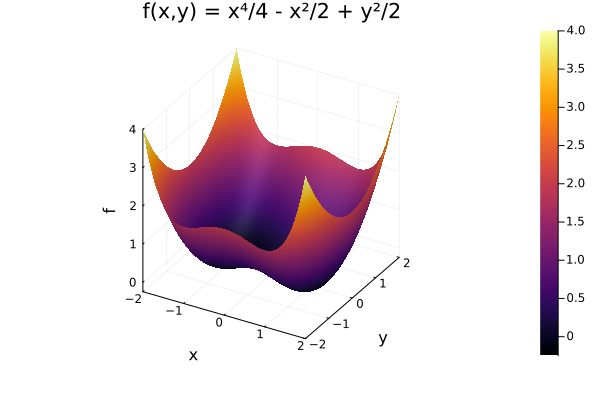

In [20]:
saddle_xy(x, y) = saddle([x, y])

x = range(-2, 2, length=200)
y = range(-2, 2, length=200)

surface(
    x, y, saddle_xy,
    xlabel = "x",
    ylabel = "y",
    zlabel = "f",
    title = "f(x,y) = x⁴/4 - x²/2 + y²/2"
)

In [21]:
# The subproblem axis, for completeness: min_{‖s‖ ≤ Δ} gᵀs + ½ sᵀHs.
# `solve_subproblem!` writes the step into `s` and returns whether ‖s‖ = Δ.
xs = collect(nlp.meta.x0)          # local names: immune to whatever else is in scope
gs = grad(nlp, xs)
s  = similar(gs)
Hs = similar(gs)

##### !!!!! NEED TO CHECK --- KrylovCGLanczos ----
for sub in (SteihaugCG(), ExactMS() , KrylovCG()) #, KrylovCGLanczos())
    active = solve_subproblem!(sub, ExactHessian(), nlp, xs, gs, 0.05, s, Hs)
    @test active                        # a small radius binds
    @test norm(s) ≈ 0.05 rtol = 1e-5
end

# Steihaug CG accumulates B·s as it goes, so the solver never recomputes it.
solve_subproblem!(SteihaugCG(), ExactHessian(), nlp, xs, gs, 0.05, s, Hs)
@test returns_hprod(SteihaugCG())
@test Hs ≈ Symmetric(dense_hessian(ExactHessian(), nlp, xs)) * s atol = 1e-10

Test Passed

In [22]:
ind = ADNLPModel(y -> 0.5y[1]^2 - 0.5y[2]^2, [1.0, 1.0])   # λ = {1, −1}
xi, gi = copy(ind.meta.x0), grad(ind, ind.meta.x0)
si, Hsi = similar(gi), similar(gi)

for sub in (KrylovCG(), KrylovCGLanczos())
    try
        act = solve_subproblem!(sub, ExactHessian(), ind, xi, gi, 0.5, si, Hsi)
        @printf("%-18s ok   active=%-5s ‖s‖=%.4f\n", nameof(typeof(sub)), act, norm(si))
    catch e
        @printf("%-18s FAILED  %s\n", nameof(typeof(sub)), typeof(e))
    end
end

KrylovCG           ok   active=true  ‖s‖=0.5000
KrylovCGLanczos    FAILED  MethodError


In [23]:
# The Cauchy-point diagnostic: at a tiny radius CG truncates on its first
# iterate, which lies along −g, so the model Hessian had no influence at all.

# cg_step_info(sub::SteihaugCG, model::ModelHessian,
#                      nlp::AbstractNLPModel{T, V}, x::V, g::V, Δ::T)

info = cg_step_info(SteihaugCG(), ExactHessian(), nlp, xs, gs, 1e-6)

@test info.cg_iters == 1
@test info.active
@test info.cos_cauchy ≈ 1.0 atol = 1e-12

Test Passed

### Residual form: `ADNLSModel`

A least-squares objective can be declared by its **residual vector** rather than by
the scalar sum. `ADNLSModel(F, x0, nequ)` takes `F(x)` returning the residuals and
the number of them. The solver takes it exactly as it takes anything else, because
it is still an `AbstractNLPModel`.

In [24]:
using ADNLPModels: ADNLSModel

F(z) = [10 * (z[2] - z[1]^2), 1 - z[1]]        # Rosenbrock as two residuals
nls  = ADNLSModel(F, [-1.2, 1.0], 2, name = "Rosenbrock (residual form)")

@test nls isa AbstractNLPModel
# ADNLSModel minimises ½‖F(x)‖², so its objective is half the scalar form above.
@test obj(nls, [-1.2, 1.0]) ≈ obj(nlp, [-1.2, 1.0]) / 2

st_nls = tr_solve(nls; rule = RDelta(), params = TRParams(tol = 1e-8))
@test st_nls.status === :first_order
@printf("residual form: %s in %d iterations, x = [%.6f, %.6f]\n",
        st_nls.status, st_nls.iter, st_nls.solution[1], st_nls.solution[2])

residual form: first_order in 32 iterations, x = [1.000000, 1.000000]


### CUTEst, and why the benchmark takes thunks

`CUTEst` is **optional**. It is not a dependency of the package and nothing else in
this notebook needs it. If it is not installed the next cell says so and skips; no
later cell depends on it.

A `CUTEstModel` holds an open handle to a Fortran library. The handle must be
released with `finalize`, and it leaks if you do not. That is why `run_matrix` takes
**thunks**, `() -> CUTEstModel(name)`, rather than built models: it opens each
problem, runs every configuration on it, and finalises it before moving on.

In [25]:
# Optional. Leave CUTEst uninstalled, or set this to false, to skip.
const USE_CUTEST = try
    @eval using CUTEst
    true
catch
    false
end

if USE_CUTEST
    cnlp = CUTEstModel("ROSENBR")
    try
        st_c = tr_solve(cnlp; rule = RDelta(), params = TRParams(tol = 1e-6))
        @printf("CUTEst ROSENBR: %s in %d iterations, f = %.3e\n",
                st_c.status, st_c.iter, st_c.objective)
    finally
        finalize(cnlp)            # release the handle, always
    end
else
    println("CUTEst not available; skipped. Nothing later depends on this cell.")
end

CUTEst ROSENBR: first_order in 32 iterations, f = 4.712e-22


---
## Part 3 — Running a solve and reading the output

`tr_solve` returns a `GenericExecutionStats` from `SolverCore`. It is a JSO type,
not a package type, so anything in the ecosystem that consumes one consumes this.

In [26]:
stats = tr_solve(nlp; rule = RGrad(μ = 1.0), model = ExactHessian(),
                 params = TRParams(tol = 1e-8), trace = true)

@test stats isa TRResult                      # const TRResult = GenericExecutionStats
@printf("status       %s\n", stats.status)
@printf("solution     [%.8f, %.8f]\n", stats.solution[1], stats.solution[2])
@printf("objective    %.3e\n", stats.objective)
@printf("dual_feas    %.3e     (norm of g at the returned point)\n", stats.dual_feas)
@printf("iter         %d\n", stats.iter)
@printf("elapsed_time %.4f s\n", stats.elapsed_time)

status       first_order
solution     [1.00000000, 1.00000000]
objective    0.000e+00
dual_feas    0.000e+00     (norm of g at the returned point)


iter         37


elapsed_time 0.0000 s


### The statuses

| status | meaning |
|:--|:--|
| `:first_order` | the gradient norm is at or below `tol` |
| `:second_order` | additionally the model's leftmost eigenvalue is at or above `-tol_H`, when `tol_H > 0` was asked for |
| `:max_iter`, `:max_time` | the budget ran out |
| `:stalled` | the step fell below the level at which `f(x) - f(x+s)` carries information, so the ratio became noise |
| `:exception` | the model could not be built at the current iterate |
| `:user` | a callback stopped the run |

`:stalled` is not a defect. Once the radius collapses far enough the subtraction
`f(x_k) - f(x_k + s_k)` is pure rounding, every step is rejected and the radius
contracts for ever. It is reported separately so that it is not silently folded
into failure.

In [27]:
# Evaluation counts come from the MODEL, not from the stats object.
counts = ADNLPModel(rosen, [-1.2, 1.0])
solver = DeterministicTRSolver(counts; rule = RGrad(μ = 1.0), model = ExactHessian(),
                               params = TRParams(tol = 1e-8))
_ = solve!(solver, counts)

@printf("neval_obj   %4d\n", neval_obj(counts))
@printf("neval_grad  %4d\n", neval_grad(counts))
@printf("neval_hprod %4d\n", neval_hprod(counts))
@printf("neval_hess  %4d\n", neval_hess(counts))

# Some model Hessians evaluate the gradient themselves. Subtract that to get the
# gradients the ITERATION used. It is non-zero only for SPDTarget.
@printf("model_grad_evals %d  (subtract from neval_grad)\n", model_grad_evals(solver))
@test model_grad_evals(solver) == 0

neval_obj     38


neval_grad    35
neval_hprod   60
neval_hess     0
model_grad_evals 0  (subtract from neval_grad)


Test Passed

### The trace, and the alignment convention

With `trace = true` the run records its trajectories into `stats.solver_specific`.

The convention is the one thing to get right. **Entry `j` describes iteration
`j-1`**, and the **state** trajectories carry one entry more than the
**per-iteration** ones, because they also record the state the final iteration left
behind. The two agree at the *head*, so to pair a state with the iteration that
produced it, drop the last entry: `delta[1:end-1]`.

Aligning on the tail instead pairs the radius of iteration `k` with the step of
iteration `k-1`, and shifts every activity, ratio and step-versus-radius plot by one
iteration.

In [28]:
ss = stats.solver_specific

state   = (:delta_trajectory, :grad_trajectory, :obj_trajectory)
periter = (:ratio_trajectory, :step_trajectory, :active_trajectory,
           :accepted_trajectory, :rho_tilde_trajectory, :gamma_trajectory,
           :xi_trajectory, :cos_cauchy_trajectory, :cg_iters_trajectory,
           :branch_trajectory)

k = stats.iter
@test all(length(ss[s]) == k + 1 for s in state)
@test all(length(ss[s]) == k     for s in periter)
@printf("iterations k = %d;  state trajectories %d,  per-iteration %d\n",
        k, length(ss[:delta_trajectory]), length(ss[:ratio_trajectory]))

# The inequality that fails if the alignment is off by one: a radius can never be
# shorter than the step taken inside it.
dtraj, straj = ss[:delta_trajectory], ss[:step_trajectory]
@test all(straj[j] <= dtraj[j] * (1 + 1e-10) for j in eachindex(straj))
println("step_j <= delta_j at the head for every j: alignment confirmed")

iterations k = 37;  state trajectories 38,  per-iteration 37


step_j <= delta_j at the head for every j: alignment confirmed


Conditional keys, present only when asked for:

| key | switched on by |
|:--|:--|
| `:lambda_min_trajectory`, `:tau_trajectory` | `tol_H > 0` |
| `:dist_trajectory` | `x_ref = ...` |
| `:lambda_min_true_trajectory` | `true_curvature = true` |
| `:hessian_norm_trajectory` | `hessian_norm = true` |

A sampled run adds `:true_grad_trajectory`, `:sigma_g2_trajectory`,
`:sigma_f2_trajectory`, `:grad_sample_trajectory`, `:obj_sample_trajectory`,
`:samples_total`, `:sample_cap_hits` and `:problem_class`; a finite sum also adds
`:full_batch_trajectory` and `:population`.

In [29]:
withref = tr_solve(nlp; rule = RGrad(μ = 1.0), model = ExactHessian(),
                   params = TRParams(tol = 1e-8, tol_H = 1e-6),
                   x_ref = [1.0, 1.0], true_curvature = true, hessian_norm = true,
                   trace = true)
extra = (:lambda_min_trajectory, :tau_trajectory, :dist_trajectory,
         :lambda_min_true_trajectory, :hessian_norm_trajectory)
@test all(haskey(withref.solver_specific, key) for key in extra)
@test !haskey(stats.solver_specific, :dist_trajectory)      # absence is unambiguous
println("conditional keys present: ", join(string.(extra), ", "))

conditional keys present: 

lambda_min_trajectory, tau_trajectory, dist_trajectory, lambda_min_true_trajectory, hessian_norm_trajectory


### Read a trace with the `Diagnostics` helpers, not by hand

They do the alignment once, and correctly.

In [30]:
theta = theta_trajectory(stats)             # theta_k = delta_k / norm(g_k)
@test length(theta) == stats.iter + 1

@printf("inactivity_index    %s\n", inactivity_index(stats))
@printf("active_fraction     %.3f  (last 20 per cent of the run)\n",
        active_fraction(stats; tail = 0.2))
@printf("kappa_bar_empirical %.4f\n", kappa_bar_empirical(stats))
@printf("kappa_bar at (1,1)  %.4f  (8/lambda*, the default convention)\n",
        kappa_bar(nlp, [1.0, 1.0]))
println("branch_counts       ", branch_counts(stats))
println("observed_order      ", observed_order(stats))
println("hypotheses_report   ", hypotheses_report(stats))

@test sum(values(branch_counts(stats))) == stats.iter

inactivity_index    32
active_fraction     0.250  (last 20 per cent of the run)


kappa_bar_empirical 2.5039
kappa_bar at (1,1)  20.0320  (8/lambda*, the default convention)


branch_counts       

Dict(:expand => 12, :contract => 3, :hold => 19, :shrink => 3)


observed_order      

(order = 1.1516582039782757, intercept = -2.7102041592046193, npts = 4, from = 32)


hypotheses_report   (xi_final = 4.582473538140181e-14, xi_max_tail = NaN, gamma_final = 7.508712419958438e-12, gamma_max_tail = NaN, rho_final = 1.0000000001602591, cauchy_fraction = 0.3783783783783784)


Test Passed

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 38 for log10 based yscale
└ @ Plots C:\Users\jerem\.julia\packages\Plots\GIume\src\utils.jl:105


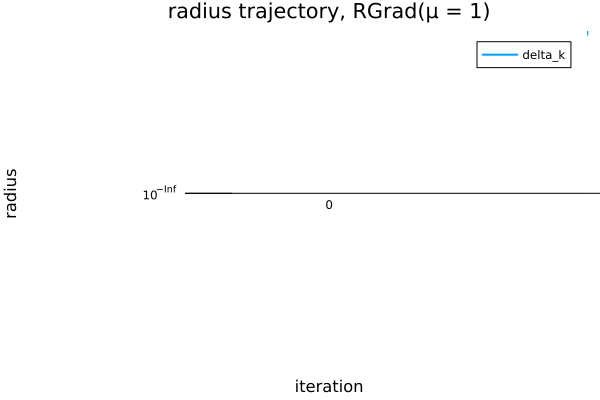

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 38 for log10 based yscale
└ @ Plots C:\Users\jerem\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 38 for log10 based yscale
└ @ Plots C:\Users\jerem\.julia\packages\Plots\GIume\src\utils.jl:105


In [31]:
plot(0:stats.iter, ss[:delta_trajectory]; yscale = :log10, lw = 2,
     label = "delta_k", xlabel = "iteration", ylabel = "radius",
     title = "radius trajectory, RGrad(μ = 1)")

---
## Part 4 — Deterministic problems

Any `AbstractNLPModel` goes straight into `tr_solve` and selects
`DeterministicTRSolver`. There is no wrapping step and no `sampling` keyword: the
sampling rule belongs to the oracle, and a deterministic run has none.

`FullBatchNLP` lands here too. It is the *exact* view of a finite-sum problem, so
although it wraps a `FiniteSumProblem` its `problem_class` is `:deterministic` and
the deterministic solver is the one selected.

In [32]:
base_fs = ADNLPModel(z -> 0.5 * sum(abs2, z .- 1), [0.0, 0.0])
fsprob  = PerturbedSum(base_fs, 400; σg = 1.0, seed = 1)

@test problem_class(nlp) === :deterministic
@test problem_class(FullBatchNLP(fsprob)) === :deterministic
@test problem_class(FiniteSumNLP(fsprob, FixedSample(32))) === :finite_sum

d1 = tr_solve(nlp; rule = RDelta())
d2 = tr_solve(FullBatchNLP(fsprob); rule = RDelta())
@printf("ADNLPModel   -> %s in %d iterations\n", d1.status, d1.iter)
@printf("FullBatchNLP -> %s in %d iterations\n", d2.status, d2.iter)

ADNLPModel   -> first_order in 32 iterations
FullBatchNLP -> first_order in 2 iterations


Two things the deterministic solver refuses, both at construction rather than by
running and producing something that looks plausible.

In [33]:
# A sampled oracle is not a deterministic problem.
err1 = try
    DeterministicTRSolver(FiniteSumNLP(fsprob, FixedSample(32)))
catch e
    e
end
@test err1 isa ArgumentError
println(sprint(showerror, err1), "\n")

# true_stop confirms a batch estimate against the truth. There is no batch here.
err2 = try
    DeterministicTRSolver(nlp; params = TRParams(true_stop = :full))
catch e
    e
end
@test err2 isa ArgumentError
println(sprint(showerror, err2))

ArgumentError: DeterministicTRSolver was given a FiniteSumNLP, which is a finite_sum oracle. Use FiniteSumTRSolver, or wrap the problem in FullBatchNLP to solve it exactly.



ArgumentError: TRParams(true_stop = :full) has no meaning for a deterministic problem: the stopping test is already the true one. Use true_stop = :none.


---
## Part 5 — Finite sums

Now the objective is estimated from a sample. There are **two** classes here, not
one, and the package keeps them apart in the type system because they need
different solvers:

| class | `f(x)` | population | cap on `N_k` | full batch? | truth? |
|:--|:--|:--|:--|:--|:--|
| **expectation** | `E_ξ[F(x,ξ)]` | unbounded | your `budget` | **never** | only if supplied |
| **finite sum** | `(1/M) Σ f_i(x)` | `M` | `M`, imposed | reachable | always, one pass |

An expectation is *not* a finite sum with a large `M`. It has no largest sample, no
iteration at which the estimate becomes exact, and therefore no way to discharge the
accuracy hypotheses of the stochastic convergence theory — you can only assume them.
A finite sum can reach `N_k = M`, where the iteration is exactly the deterministic
one.

Three pieces in either case: a **problem** (where the randomness lives), a
**sampling rule** (how `N_k` is chosen — the axis under study), and an **oracle**
(`FiniteSumNLP` or `ExpectationNLP`) satisfying the ordinary NLP interface, so every
rule, model and subsolver above runs over it unchanged.

### The base problem

The base is a separable strictly convex quadratic,

$$f(z) = \tfrac12 \sum_{i=1}^{4} i\,(z_i - 1)^2
       = \tfrac12 (z - \mathbf{1})^\top D (z - \mathbf{1}),
\qquad D = \operatorname{diag}(1,2,3,4).$$

Everything about it is closed form:

| quantity | value |
|:--|:--|
| $\nabla f(z)$ | $D(z - \mathbf{1})$ |
| $\nabla^2 f(z)$ | $D$, constant and positive definite |
| minimiser $z^\star$ | $\mathbf{1} = (1,1,1,1)$, unique |
| $f(z^\star)$ | $0$ |
| spectrum of $\nabla^2 f$ | $\{1,2,3,4\}$, so $\lambda_{\min}=1$, $\lambda_{\max}=4$ |
| condition number | $\kappa = 4$ — well conditioned |

Because the Hessian is constant, the second-order model is *exact everywhere*, and a
Newton step reaches $z^\star$ from any starting point in one iteration. That is the
whole reason to choose it as a testbed base: with `ExactMS` and no noise the run
terminates immediately, so **any iteration count above one is attributable to the
sampling rule, not to the geometry of $f$.** The confounder is removed by
construction.

In [34]:
base = ADNLPModel(z -> 0.5 * sum(collect(1.0:4) .* (z .- 1.0).^2), zeros(4), name = "quad");

### `PerturbedSum`

`PerturbedSum(base, 2_000; σg = 1.0, seed = 3)` turns that single objective into an
average of $M = 2000$ terms:

$$F_i(x) = f_{\text{base}}(x) + b_i^\top x + \tfrac12 x^\top C_i x,
\qquad f(x) = \frac1M \sum_{i=1}^M F_i(x).$$

The constructor, step by step:

1. Draws $b \in \mathbb{R}^{4 \times 2000}$ with entries $\sim N(0, \sigma_g^2)$ from
   `MersenneTwister(3)` — the `seed` fixes the entire dataset, so the problem is
   byte-for-byte reproducible.
2. **Centres it:** $b \leftarrow b - \frac1M\sum_i b_i$, so $\sum_i b_i = 0$ to
   machine precision.
3. Since `σH = 0`, sets every $C_i = 0$.

Step 2 is what makes the mean *exact* rather than merely correct in expectation:

$$\frac1M \sum_{i=1}^M F_i(x)
= f_{\text{base}}(x) + \Big(\tfrac1M\textstyle\sum_i b_i\Big)^{\!\top} x
= f_{\text{base}}(x) \quad\text{identically in } x.$$

A general finite sum only satisfies this in the limit; this one satisfies it at every
$x$ and every realisation, which is the property the controlled experiment rests on.

#### Why it is the right noise

- **The estimation error is known, not bounded.** A batch $B$ gives
  $$\hat g(x) = \nabla f_{\text{base}}(x) + \frac{1}{|B|}\sum_{i\in B} b_i,$$
  so the error is exactly the batch mean of the drawn $b_i$. `true_gradient(prob, x)`
  returns $\nabla f_{\text{base}}(x)$ at the cost of one base gradient, and
  `has_truth(prob)` is `true`. Every reported number can therefore be scored against
  the answer instead of against another estimate.

- **Common random numbers behave as on a real empirical risk.** The perturbations are
  smooth in $x$ (here linear), so the same $b_i$ enter $\hat f(x_k)$ and
  $\hat f(x_k + s_k)$, and the difference's variance shrinks with $\|s_k\|$ rather
  than staying flat. A construction that re-randomised per evaluation would make
  $\hat\rho$ pure noise at small radii — the failure the CRN section is about.

- **The full batch is the deterministic problem.** At $N_k = M = 2000$ the estimate
  equals $f_{\text{base}}$ exactly, so `FiniteSumNLP(prob, FullBatch())` reproduces
  `DeterministicTRSolver` on `FullBatchNLP(prob)` iterate for iterate. An expectation
  has no such limit — the substantive difference between the two sampled classes.

#### Two things to watch

- **The Hessian is noiseless.** With `σH = 0` every $C_i = 0$, so
  `batch_hess(prob, x, batch)` returns $D$ *exactly*, whatever the batch — only $f$
  and $\nabla f$ carry noise. Pass `σH > 0` to perturb the model Hessian too, at which
  point BHHH and Gauss–Newton start to see sampling error in the curvature as well.

- **The variance the rules see is $n\sigma_g^2$, not $\sigma_g^2$.** Because $b_i$ has
  $n = 4$ independent components,
  $$\sigma_g^2 \;\text{(as the rules define it)} \;=\;
    \operatorname{tr}\operatorname{Var}(\nabla F_i) \;=\; n\,\sigma_g^2 \;=\; 4.$$
  When hand-checking `RadiusProportional`, $N_k = (\sigma_g/(\kappa_g \Delta_k))^2$
  uses $\sigma_g = 2$. This is the discrepancy behind the `SamplingState(3, 0.1, 2.0,
  4.0, 9.0)` in the sizing test — the `4.0` is $\sigma_g^2$, and its square root is
  the `2` the formula wants.
  

In [35]:
# The finite-sum version: M centred perturbations, so at N = M the estimate is exact.
prob = PerturbedSum(base, 2_000; σg = 1.0, seed = 3)

PerturbedSum{ADNLPModel{Float64, Vector{Float64}, Vector{Int64}}}(ADNLPModel - Model with automatic differentiation backend ADModelBackend{
  ForwardDiffADGradient,
  ForwardDiffADHvprod,
  EmptyADbackend,
  EmptyADbackend,
  EmptyADbackend,
  SparseADHessian,
  EmptyADbackend,
}
  Problem name: quad
   All variables: ████████████████████ 4      All constraints: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
            free: ████████████████████ 4                 free: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
           lower: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0                lower: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
           upper: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0                upper: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
         low/upp: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0              low/upp: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
           fixed: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0                fixed: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
          infeas: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0               infeas: ⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅⋅ 0     
            nnzh: ( 60.00% sparsity)   4               linear

In [36]:
@testset "Perturbed Sum" begin
    @test prob isa FiniteSumProblem
    @test population(prob) == 2_000
    @test has_truth(prob)
end

xq = [0.3, -0.7, 1.4, 0.2]

# The full sum reproduces the base model exactly — that is the construction.
@testset "Full-batch equivalence" begin
    @test batch_obj(prob, xq, full_batch(prob)) ≈ obj(base, xq) rtol = 1e-10

    gg = zeros(4); batch_grad!(prob, xq, full_batch(prob), gg)
    @test gg ≈ grad(base, xq) rtol = 1e-10
    
    @test true_gradient(prob, xq) ≈ grad(base, xq)
end

# A subsample is biased away from it at the Monte Carlo rate.
errs = Float64[]
for N in (4, 64, 1024)
    rng = MersenneTwister(1)
    push!(errs, mean(1:40) do _
        b = rand(rng, 1:2_000, N); h = zeros(4)
        batch_grad!(prob, xq, b, h); norm(h - grad(base, xq))
    end)
end
@test errs[1] > errs[2] > errs[3]

println("──────────────────────────────────────────────")
@printf("%-12s │ %12s\n", "N", "‖ĝ − ∇f‖")
println("──────────────────────────────────────────────")

@printf("%-12d │ %12.4f\n", 4,    errs[1])
@printf("%-12d │ %12.4f\n", 64,   errs[2])
@printf("%-12d │ %12.4f\n", 1024, errs[3])

println("──────────────────────────────────────────────")
@printf("Expected rate: ≈ N^{-1/2}\n")


Test Summary: | Pass  Total  Time
Perturbed Sum |    3      3  0.0s


Test Summary:          | Pass  Total  Time
Full-batch equivalence |    3      3  0.6s


──────────────────────────────────────────────


N            │     ‖ĝ − ∇f‖
──────────────────────────────────────────────


4            │       0.9439
64           │       0.2256
1024         │       0.0577
──────────────────────────────────────────────
Expected rate: ≈ N^{-1/2}


### `FiniteSumNLP`

The general-purpose finite-sum problem: you supply three per-term callbacks, it
becomes an empirical risk

$$f(x) = \frac1M \sum_{i=1}^{M} F_i(x),$$

that any sampling rule, model Hessian and subsolver in the package can run over. It is
the escape hatch below the packaged problems (`LogisticRegression`, `LeastSquares`,
`MLPClassifier`) — reach for it when your objective is a sum over data but is not one
of those.

### Type

```julia
struct FiniteSum{FF, GG, HH} <: FiniteSumProblem
    n::Int      # number of variables
    M::Int      # number of terms
    Fi::FF      # Fi(i, x)     -> Real
    Gi!::GG     # Gi!(i, x, g) -> nothing, accumulating ∇Fᵢ(x) into g
    Hi::HH      # Hi(i, x)     -> AbstractMatrix, the n×n term Hessian
end
```

It sits at the base of the [problem-class hierarchy](problem_classes.md) as a direct
child of `FiniteSumProblem` — a *finite sum*, but **not** a `ScoredProblem`. That
placement is the substantive part of the type, and it decides what is allowed:

| trait | value | consequence |
|:--|:--|:--|
| `population(p)` | `M` | `N_k ≤ M`; the cap is the problem's, not a keyword |
| `has_scores(p)` | `false` | no per-observation gradients exposed |
| `has_truth(p)` | `true` | `true_gradient` available at one full pass |

The three callbacks parametrise the struct (`FF, GG, HH`), so each `FiniteSum` you
build is its own concrete type and the calls to `Fi`, `Gi!`, `Hi` inline rather than
dispatching dynamically.

### The three callbacks

- **`Fi(i, x) -> Real`** — the value of term $i$. The batch objective is their mean,
  $\hat f(x) = \frac{1}{|B|}\sum_{i \in B} F_i(x)$.
- **`Gi!(i, x, g)`** — **accumulates** $\nabla F_i(x)$ into `g` (`g .+=`), rather than
  overwriting it. Accumulation is what lets `batch_grad!` sum a batch into one buffer
  without allocating per term.
- **`Hi(i, x) -> AbstractMatrix`** — the $n \times n$ term Hessian. Called **only** by
  `ExactHessian`; a quasi-Newton or a matrix-free run never touches it, so if you only
  ever use `SR1Model`/`LBFGSModel` you can supply a stub.

### What you get, and what you do not

Because `FiniteSum` is not a `ScoredProblem`:

- ✅ `ExactHessian`, `SR1Model`, `LBFGSModel`, `ScaledIdentity`, `SPDTarget` — anything
  needing only $f$, $\nabla f$, $\nabla^2 f$.
- ✅ `FixedSample`, `RadiusProportional`, `NormTest`, `GeometricSample`,
  `SequentialEstimation`, `FullBatch` — the rules that size from the gradient and
  objective variances.
- ❌ `BHHHModel`, `GaussNewtonModel` — they need per-observation scores; use a
  `LikelihoodProblem` / `NLSProblem` (or `PerturbedSum`, or the packaged problems).
- ❌ `InnerProductTest`, `OrthogonalityTest`, `AugmentedInnerProduct` — they need
  $\operatorname{Var}(\nabla F_i^\top \hat g)$, which is a scores quantity. Rejected at
  oracle construction by `check_rule_problem`, not at the first iteration.

If you need those, supply the scores instead — i.e. subtype `ScoredProblem` and define
`scores(p, x, batch)` and `loss_terms(p, x, batch)`, which is what the packaged
problems do.

### Why the callback form pays off

Subsampling is subsetting the index set `1:M`, so the oracle draws a `Vector{Int}` and
the same indices evaluate $\hat f(x_k)$ and $\hat f(x_k + s_k)$ — **common random
numbers for free**. The noise in $\hat f(x_k) - \hat f(x_k + s_k)$ then cancels to the
extent the $F_i$ are smooth, which is what keeps $\hat\rho$ usable once $\|s_k\|$ falls
below the sampling error. A construction that re-randomised per evaluation would make
$\hat\rho$ pure noise at small radii.

### Variance estimates

`grad_variance` and `obj_variance` are computed by re-running the callbacks over the
batch — `grad_variance` calls `Gi!` once per term into a scratch vector to form
$\operatorname{tr}\operatorname{Var}(\nabla F_i)$. That is the price of the general
interface: without a score matrix there is no one-pass shortcut, so on a large batch
the variance estimate costs a second sweep of gradient evaluations. A `ScoredProblem`
gets all four moments from a single `scores` call; `FiniteSum` trades that efficiency
for not having to expose scores at all.

### Minimal example

```julia
# f(x) = (1/M) Σ ½ aᵢ (x − cᵢ)²  — a separable per-term quadratic
using Random
rng = MersenneTwister(0)
n, M = 3, 500
A = rand(rng, M) .+ 0.5              # per-term curvatures
C = randn(rng, n, M)                 # per-term centres

Fi(i, x)     = 0.5 * A[i] * sum(abs2, x .- view(C, :, i))
Gi!(i, x, g) = (g .+= A[i] .* (x .- view(C, :, i)); nothing)   # accumulates
Hi(i, x)     = A[i] * Matrix(I, n, n)

prob = FiniteSum(n, M, Fi, Gi!, Hi)

population(prob)              # 500
has_scores(prob)             # false
true_gradient(prob, zeros(n))   # exact ∇f, one pass over all 500 terms

# wrap and solve
nlp = FiniteSumNLP(prob, RadiusProportional(); seed = 1)
tr_solve(nlp; rule = RDelta(), subsolver = ExactMS(),
         params = TRParams(tol = 1e-6))
```

!!! note "`Gi!` accumulates — do not overwrite"
    The single most common mistake is writing `g .= …` instead of `g .+= …`. With
    overwrite, `batch_grad!` returns only the last term's gradient rather than the
    batch mean, and the run walks in a plausible-looking wrong direction with nothing
    in the trace to flag it. `Gi!` must leave `g` holding its incoming value plus
    $\nabla F_i$.

### Problem or oracle: which is which

|  | `FiniteSum` and `PerturbedSum` | `FiniteSumNLP` |
|:--|:--|:--|
| **what it is** | the problem — the maths | the oracle — the solver's interface |
| **subtype of** | `FiniteSumProblem` | `SampledNLP <: AbstractNLPModel` |
| **holds** | `n`, `M` and three pure callbacks | a problem, a sampling rule, RNG, current batch, variances, counters, Hessian cache (28 fields) |
| **mutable?** | no — immutable, stateless | yes — carries all per-run state |
| **knows about sampling?** | no | yes: draws batches, sizes them, tracks cost |
| **the solver calls** | never directly | `obj`, `grad!`, `hess` on this |

### What `resample!` does

```julia
resample!(m::SampledNLP, k::Int, Δ::Real, g_norm::Real) --> return Ng, Nf
```

In [37]:
# The finite-sum oracle. N_k ≤ M is imposed by the problem, so no N_max is needed —
# and a rule carrying one is rejected here, because on a finite sum that keyword is
# either redundant or a deliberate sub-population budget, and those are different
# intentions.

finite_sum_nlp = FiniteSumNLP(prob, FixedSample(64); seed = 1) # prob shoulb the previous PerturbedSum

@testset "FiniteSumNLP" begin
    @test problem_class(finite_sum_nlp) === :finite_sum
    @test population_cap(finite_sum_nlp) == 2_000
    @test_throws ArgumentError FiniteSumNLP(prob, RadiusProportional(N_max = 500))
    @test FiniteSumNLP(prob, RadiusProportional(); budget = 500) isa FiniteSumNLP  # deliberate
end

@testset "Sampling" begin
    resample!(finite_sum_nlp, 1, 1.0, 1.0)          # draw the batch for iteration 1
    @test length(finite_sum_nlp.batch_g) == 64
    @test finite_sum_nlp.batch_f === finite_sum_nlp.batch_g      # shared batch ⇒ common random numbers
end

@testset "FiniteSumNLP: obj, gradient, Hessian" begin
    gb = zeros(4); grad!(finite_sum_nlp, xq, gb)
    @test obj(finite_sum_nlp, xq) isa Real
    @test size(Matrix(hess(finite_sum_nlp, xq))) == (4, 4)
    @test samples_used(finite_sum_nlp).total == 128            # 64 gradient + 64 objective terms
end

@testset "Reproducibility" begin
    reset_sampling!(finite_sum_nlp)
    # Reproducibility: reset restores the RNG *and* the batches.
    first_batch = copy(finite_sum_nlp.batch_g)
    gb1 = zeros(4); grad!(finite_sum_nlp, xq, gb1)
    for k in 1:5; resample!(finite_sum_nlp, k, 1.0, 1.0); end

    reset_sampling!(finite_sum_nlp)
    gb2 = zeros(4); grad!(finite_sum_nlp, xq, gb2)

    @test finite_sum_nlp.batch_g == first_batch 
    @test gb1 ≈ gb2 rtol = 1e-10
    
    @test isempty(finite_sum_nlp.Ng_hist) 
    @test samples_used(finite_sum_nlp).total == 0
    # @test gb1 ≈ gb2 rtol = 1e-10

    @test isempty(finite_sum_nlp.Ng_hist)
    @test samples_used(finite_sum_nlp).total == 0 
end

println("FiniteSumNLP satisfies the NLP interface, and resets cleanly ✓")

Test Summary: | 

Pass  Total  Time
FiniteSumNLP  |    4      4  0.2s
Test Summary: | Pass  Total  Time
Sampling      |    2      2  0.0s
Test Summary:                        | 

Pass  Total  Time
FiniteSumNLP: obj, gradient, Hessian |    3      3  1.3s


Test Summary:   | Pass  Total  Time
Reproducibility |    6      6  0.1s
FiniteSumNLP satisfies the NLP interface, and resets cleanly ✓


### `PerturbedExpectation`

It is the same construction without the finite population: the
perturbations are drawn fresh, so their sample mean is `O(σ/√N)` at **every** `N`.
There is no sample size at which the estimate becomes exact, and no full batch to fall
back on — which is exactly what the type is carrying.

An objective given as a genuine **expectation**,

$$f(x) = \mathbb{E}_{\xi}\!\left[\, f_{\text{base}}(x) + b(\xi)^\top x
        + \tfrac12 x^\top C(\xi)\, x \,\right],
\qquad b \sim N(0, \sigma_g^2 I),\; C \text{ symmetric, mean zero},$$

whose mean is exactly a known model $f_{\text{base}}$. It is the **expectation twin of
[`PerturbedSum`](@ref)**, and it exists so the expectation branch of the
[problem-class hierarchy](problem_classes.md) has a controlled test problem — one where
the exact answer is known even though no finite dataset underlies it.

### Type

```julia
struct PerturbedExpectation{P} <: ExpectationProblem
    base::P        # the model whose value is the exact mean
    n::Int         # number of variables
    σg::Float64    # gradient-noise scale
    σH::Float64    # Hessian-noise scale (0 ⇒ noiseless curvature)
end

PerturbedExpectation(base; σg = 1.0, σH = 0.0)
```

It is an `ExpectationProblem`, and every consequence below follows from that placement
rather than from the specific perturbation:

| trait | value | why |
|:--|:--|:--|
| `population(p)` | `typemax(Int)` | the population is unbounded — there is no `M` |
| `has_scores(p)` | `false` | no per-observation decomposition of a draw |
| `has_truth(p)` | **`true`** | this construction supplies the exact mean; a general expectation would not |

### The one difference from `PerturbedSum`, and why it is the whole point

Both wrap the same algebra around `base`. The difference is a single line in how a
batch is drawn:

- **`PerturbedSum`** draws $M$ perturbations once and **centres** them, $\sum_i b_i = 0$.
  So at $N = M$ the estimate is *exact*, and the accuracy hypotheses of the stochastic
  convergence theory are discharged rather than assumed.
- **`PerturbedExpectation`** draws **fresh** every time and does **not** centre — the
  sample mean of $b$ is $O(\sigma_g/\sqrt{N})$ at *every* $N$. There is **no sample
  size at which the estimate becomes exact**, and no full batch to fall back on.

```julia
b = p.σg .* randn(rng, p.n, N)     # NOT centred: that is the point
```

That non-centring is not an oversight — it is the defining property of an expectation.
A finite sum can be exhausted; an expectation can only be sampled. Encoding the two as
sibling types, rather than as one type with a large `M`, is what lets the solver refuse
the operations that only make sense on one side:

- `FullBatch()` is **rejected** — "all of it" is not a sample size an expectation has.
- The accuracy theory can never be discharged by sampling harder, so `:samples_total`
  is the only honest cost measure and there is no `:full_batch_trajectory`.

### Why it still has a truth

`base` is available in closed form, so

```julia
true_objective(p, x) = obj(p.base, x)
true_gradient(p, x)  = grad(p.base, x)
```

are exact at no sampling cost, and `has_truth(p)` is `true`. This is what makes it the
*right* expectation problem for a controlled experiment: the estimation error at every
iterate is known, not merely bounded, even though the population is infinite.

The practical payoff is that `TRParams(true_stop = true)` works here. A stopping test on
$\|\hat g_k\| \le \text{tol}$ is a statement about one batch, and a mechanism that shrinks
the radius fast enough will meet it on noise alone; with a truth available, the solver can
confirm the test against $\nabla f_{\text{base}}$ before declaring convergence. A general
expectation has no such handle, and `true_stop` on one is an `ArgumentError`, not a silent
fallback.

### The batch object

An expectation batch is **data, not indices**. `draw_batch` returns a
[`GaussianDraw`](@ref) holding the $n \times N$ matrix of drawn $b_i$ and, when
$\sigma_H > 0$, a vector of $N$ symmetric perturbation matrices $C_i$:

```julia
struct GaussianDraw
    b::Matrix{Float64}
    C::Union{Nothing, Vector{Matrix{Float64}}}
end
```

This is the concrete reason `batch_obj`, `batch_grad!` and friends take an opaque `batch`
argument rather than a `Vector{Int}`: a finite-sum batch *is* a set of indices into
`1:M`, but an expectation batch carries the realisations themselves, because there is no
list to index into.

### Curvature noise

With the default $\sigma_H = 0$, `C` is `nothing`: the Hessian is $\nabla^2 f_{\text{base}}$
exactly, whatever the batch, and only $f$ and $\nabla f$ are noisy. Pass $\sigma_H > 0$ to
perturb the model Hessian too — each $C_i$ is drawn, symmetrised $(A + A^\top)/2$, and
added to the base Hessian in `batch_hess`. Note these draws are **not** mean-zero across a
finite batch (only in expectation), consistent with everything else in the type.

### Example

```julia
using TrustRegionRadius, ADNLPModels, LinearAlgebra, Random

base  = ADNLPModel(z -> 0.5 * sum(collect(1.0:4) .* (z .- 1).^2), zeros(4))
eprob = PerturbedExpectation(base; σg = 1.0)

population(eprob)          # typemax(Int) — unbounded
has_truth(eprob)           # true

# The estimate shrinks with N but never reaches zero — contrast PerturbedSum,
# where the full batch IS the truth.
rng = MersenneTwister(3); x = [0.3, -0.7, 1.4, 0.2]
for N in (64, 4096)
    d = draw_batch(eprob, rng, N)
    g = zeros(4); batch_grad!(eprob, x, d, g)
    println(N, "  →  ‖ĝ − ∇f‖ = ", norm(g - true_gradient(eprob, x)))
end

# The oracle needs a budget, because there is no M to cap against.
nlp = ExpectationNLP(eprob, RadiusProportional(); budget = 50_000)
population_cap(nlp)        # 50000

# FullBatch has no meaning here, and the type says so.
ExpectationNLP(eprob, FullBatch())     # ArgumentError

tr_solve(nlp; rule = RDelta(), subsolver = ExactMS(),
         params = TRParams(tol = 1e-4, true_stop = true))
```

!!! note "Where the cap comes from"
    An expectation has no population to cap against, so the budget lives on the oracle
    (`ExpectationNLP(...; budget = …)`) and, optionally, on the rule (`N_max`). Both are
    legitimate here — unlike on a finite sum, where a rule's `N_max` is rejected because
    the cap is the problem's `M`. See [Problem classes](problem_classes.md).

In [38]:
eprob = PerturbedExpectation(base; σg = 1.0)

@testset "PerturbedExpectation" begin
    @test eprob isa ExpectationProblem
    @test population(eprob) == typemax(Int)      # unbounded, not an error
    @test has_truth(eprob)                       # this construction supplies the mean
end

# The estimate shrinks with N but never reaches zero — contrast PerturbedSum above,
# where the full batch IS the truth.
rng = MersenneTwister(3)
println("──────────────────────────────────────────────")
@printf("%-15s │ %12s\n", "N", "‖ĝ − ∇f‖")
println("──────────────────────────────────────────────")

for N in (64, 4096)
    d = draw_batch(eprob, rng, N)
    g = zeros(4)
    batch_grad!(eprob, xq, d, g)
    err = norm(g - true_gradient(eprob, xq))
    @printf("%-15d │ %12.5f\n", N, err)
end
println("──────────────────────────────────────────────")

# The oracle needs a budget, because there is no M to cap against.
en = ExpectationNLP(eprob, RadiusProportional(); budget = 50_000)

@testset "ExpectationNLP" begin
    @test en isa ExpectationNLP
    @test problem_class(en) === :expectation
    @test population_cap(en) == 50_000
    @test ExpectationNLP(eprob, RadiusProportional(); budget = 500) isa ExpectationNLP  # deliberate
end

# FullBatch has no meaning here, and the type says so rather than allocating typemax(Int).
@testset "ExpectationNLP: FullBatch" begin
    @test_throws ArgumentError ExpectationNLP(eprob, FullBatch()) # no finite population
end

Test Summary:        | Pass  Total  Time
PerturbedExpectation |    3      3  0.0s
──────────────────────────────────────────────
N               │     ‖ĝ − ∇f‖
──────────────────────────────────────────────


64              │      0.23017
4096            │      0.02295
──────────────────────────────────────────────
Test Summary:  | Pass  Total  Time
ExpectationNLP |    4      4  0.0s


Test Summary:             | Pass  Total  Time
ExpectationNLP: FullBatch |    1      1  0.0s


Test.DefaultTestSet("ExpectationNLP: FullBatch", Any[], 1, false, false, true, 1.787157476521e9, 1.787157476542e9, false, "In[38]")

### The full-batch reference

On a finite sum, `FullBatch()` gives `N_k = M` at every iteration — which *is* the
deterministic run: `ρ̂ = ρ`, the stopping test is the real one, and the accuracy
hypotheses are discharged rather than assumed.

That makes it the only place the sampled and exact code paths can be compared iterate
for iterate, so it pins the resampling logic against a reference that has none.

In [39]:
# The finite-sum version: M centred perturbations, so at N = M the estimate is exact.
p = TRParams(tol = 1e-8, max_iterations = 2_000)

println("──────────────────────────────────────────────")
println("Full-batch solve as DETERMINISTIC with x0 = " , eprob.base.meta.x0)
det = tr_solve(FullBatchNLP(prob); 
                        rule = RDelta(), subsolver = SteihaugCG(),
                        model = ExactHessian(), 
                        params = p, trace = true)
println(" --- Result : ", det.status, " ---")

println("──────────────────────────────────────────────")
println("Full-batch solve as STOCHASTIC with FULL-BATCH  with x0 = " , eprob.base.meta.x0)

fs  = tr_solve(FiniteSumNLP(prob, FullBatch()); 
                    rule = RDelta(), subsolver = SteihaugCG(),
                        model = ExactHessian(), 
                        params = p, trace = true)
println(" --- Result : ", fs.status, " ---");
println("──────────────────────────────────────────────")

@testset "Full-batch equivalence" begin
    @test det.objective ≈ fs.objective rtol = 1e-10
    @test det.solution ≈ fs.solution rtol = 1e-1
    @test det.status === fs.status
    @test det.iter == fs.iter
end
@printf("──────────────────────────────────────────────\n")
@printf("deterministic: %d iters, f = %.6e\nfull batch   : %d iters, f = %.6e  (identical)\n",
        det.iter, det.objective, fs.iter, fs.objective)

──────────────────────────────────────────────
Full-batch solve as DETERMINISTIC with x0 = 

[0.0, 0.0, 0.0, 0.0]
 --- Result : 

first_order ---
──────────────────────────────────────────────
Full-batch solve as STOCHASTIC with FULL-BATCH  with x0 = [0.0, 0.0, 0.0, 0.0]
 --- Result : 

first_order ---
──────────────────────────────────────────────
Test Summary:          | Pass  Total  Time
Full-batch equivalence |    4      4  0.0s
──────────────────────────────────────────────
deterministic: 5 iters, f = -4.336809e-19
full batch   : 5 iters, f = -4.336809e-19  (identical)


### Common random numbers

The batch is drawn once per iteration and then **held fixed**, so `f̂(x_k)` and
`f̂(x_k + s_k)` use the same realisations. This is not an optimisation.

With independent draws, the variance of `f̂(x_k) − f̂(x_k+s_k)` does **not** shrink
as `‖s_k‖ → 0`, so `ρ̂` becomes pure noise at small radii and every mechanism stalls
for a reason that has nothing to do with the mechanism.

In [40]:
rng = MersenneTwister(2)
xc = fill(0.5, 4); d = [1.0, 0.0, 0.0, 0.0]

@testset "Stochastic vs deterministic" begin
    for α in (1e-1, 1e-3)
    sα = α .* d
    crn = Float64[]; ind = Float64[]
    for _ in 1:200
        b1 = rand(rng, 1:2_000, 64); b2 = rand(rng, 1:2_000, 64)
        truth = true_objective(prob, xc) - true_objective(prob, xc .+ sα)
        push!(crn, batch_obj(prob, xc, b1) - batch_obj(prob, xc .+ sα, b1) - truth)
        push!(ind, batch_obj(prob, xc, b1) - batch_obj(prob, xc .+ sα, b2) - truth)
    end
    @test std(crn) < std(ind)
    @printf("‖s‖ = %.0e :  std(shared batch) = %.2e   std(independent) = %.2e\n",
            α, std(crn), std(ind))
    end
end
println("──────────────────────────────────────────────")
println("SUMMARY : shared: error shrinks with ‖s‖.  independent: it does not.")


‖s‖ = 1e-01 :  std(shared batch) = 1.16e-02   std(independent) = 1.64e-01


‖s‖ = 1e-03 :  std(shared batch) = 1.23e-04   std(independent) = 1.66e-01
Test Summary:               | Pass  Total  Time
Stochastic vs deterministic |    2      2  0.6s
──────────────────────────────────────────────
SUMMARY : shared: error shrinks with ‖s‖.  independent: it does not.

---
## Part 6 — Expectations, and the sampling rules

The accuracy requirements for convergence of a stochastic trust-region method are
stated **in terms of the radius**: the model must be fully linear on `B(x_k, Δ_k)` and
the function estimates accurate to `O(Δ_k²)`. For a Monte Carlo estimator that means

$$N_k^{\text{grad}} \sim \Theta(\Delta_k^{-2}), \qquad
  N_k^{\text{obj}}  \sim \Theta(\Delta_k^{-4}).$$

So the total work is `Σ_k Δ_k^{-2}` — **the reciprocal of the `Σ_k Δ_k²` summability
the deterministic theory prefers.** The ranking of the mechanisms inverts: a rule with
`Δ_k → 0` pays unboundedly per iteration near the solution; a rule with
`liminf Δ_k > 0` does not.

That is why iteration counts are the wrong cost measure and `samples_used` is recorded
alongside them. `tr_solve` picks the solver from the oracle, so the regime is decided
by what you built.

In [41]:
# The sampling rules, and what each one is allowed to do.
rules = [("FullBatch",             FullBatch()),
         ("FixedSample",           FixedSample(64)),
         ("RadiusProportional",    RadiusProportional()),
         ("NormTest",              NormTest(θ = 0.5)),
         ("GeometricSample",       GeometricSample(N₀ = 8, rate = 1.1)),
         ("InnerProductTest",      InnerProductTest(N_min = 8)),
         ("OrthogonalityTest",     OrthogonalityTest(N_min = 8)),
         ("AugmentedInnerProduct", AugmentedInnerProduct(N_min = 8)),
         ("SequentialEstimation",  SequentialEstimation(N_min = 8))]

@printf("%-24s %-9s %-9s %-16s %s\n", "rule", "couples", "scores", "finite sum only", "user cap")
for (name, r) in rules
    @printf("%-24s %-9s %-9s %-16s %s\n", name, couples_to_radius(r), needs_scores(r),
            requires_finite_population(r), something(user_cap(r), "—"))
end

@testset "Sample size arithmetic" begin
    # The arithmetic, on a hand-checkable state: σg = 2, σf = 3, ‖ĝ‖ = 2, Δ = 0.1.
    st = SamplingState(3, 0.1, 2.0, 4.0, 9.0)
    @test grad_sample_size(RadiusProportional(), st) == 400      # (2/0.1)²
    @test obj_sample_size(RadiusProportional(), st)  == 90_000   # (3/0.01)²
    @test grad_sample_size(NormTest(θ = 0.5), st) == 4           # 4/(0.25·4)
    # N ~ Δ^{-2}: halving the radius quadruples the sample.
    @test grad_sample_size(RadiusProportional(), SamplingState(3, 0.05, 2.0, 4.0, 9.0)) == 1_600
end

rule                     couples   scores    finite sum only  user cap


FullBatch                false     false     true             —
FixedSample              false     false     false            —
RadiusProportional       true      false     false            —
NormTest                 false     false     false            —
GeometricSample          false     false     false            —


InnerProductTest         false     true      false            —
OrthogonalityTest        false     true      false            —
AugmentedInnerProduct    false     true      false            —
SequentialEstimation     true      false     false            —
Test Summary:          | 

Pass  Total  Time
Sample size arithmetic |    4      4  0.1s


Test.DefaultTestSet("Sample size arithmetic", Any[], 4, false, false, true, 1.787157482329e9, 1.787157482385e9, false, "In[41]")

In [42]:
# The requirement routinely exceeds typemax(Int) — at Δ = 1e-8 with σ_f = 1 it is 1e32
# against a maximum representable 9.2e18 — so the conversion saturates at the cap
# instead of raising InexactError.
@testset "Sample size saturation" begin
    @test TrustRegionRadius._sample_size(1e40, 2, 10^6) == 10^6
    @test TrustRegionRadius._sample_size(Inf,  2, 10^6) == 10^6
end

@testset "Sample size bounds" begin
    extreme = SamplingState(9_999, 1e-12, 1e-14, 1e6, 1e6, 1e6, 1e6, 1e-40, 8)
    for (name, r) in rules
        name == "FullBatch" && continue          # reads N_pop, which `extreme` leaves unbounded
        reset_sampling_rule!(r)
        N = grad_sample_size(r, extreme)
        @test N isa Int && 1 <= N <= sample_cap(r)
    end
end
println(" ──────────────────────────────────────────────")
println("every sampling rule survives a late-stage, tiny-radius state ✓")

Test Summary:          | Pass  Total  Time
Sample size saturation |    2      2  0.0s


Test Summary:      | Pass  Total  Time
Sample size bounds |    8      8  0.2s
 ──────────────────────────────────────────────
every sampling rule survives a late-stage, tiny-radius state ✓


In [43]:
# The experiment the layer exists for: hold the sampling rule fixed, vary the radius
# mechanism, and compare *samples*, not iterations.
function run_finitesum(rule, sampler; iters = 100)
    nlp = FiniteSumNLP(prob, sampler; seed = 1)
    st = tr_solve(nlp; rule = rule, model = ExactHessian(),
                  trace = true, params = TRParams(tol = 1e-6, max_iterations = iters))
    ss = st.solver_specific
    return (status = st.status, iters = st.iter, samples = ss[:samples_total],
            N_end = ss[:grad_sample_trajectory][end], Δ_end = ss[:final_delta],
            true_g = ss[:true_grad_trajectory][end],
            full = count(ss[:full_batch_trajectory]))
end

@printf("%-10s %-11s %6s %10s %8s %10s %10s %6s\n",
        "rule", "sampler", "iters", "samples", "N_end", "Δ_end", "‖∇f‖", "exact")
for rname in ("RDelta", "RDFO")
    rule = rname == "RDelta" ? RDelta() : RDFO(ζ = 1.0)
    for (sname, sampler) in (("Fixed", FixedSample(64)),
                             ("RadiusProp", RadiusProportional()))
        r = run_finitesum(rule, sampler)
        @test r.status in (:first_order, :max_iter, :stalled)
        @test r.samples > 0
        @printf("%-10s %-11s %6d %10d %8d %10.2e %10.2e %6d\n",
                rname, sname, r.iters, r.samples, r.N_end, r.Δ_end, r.true_g, r.full)
    end
end

rule       sampler      iters    samples    N_end      Δ_end       ‖∇f‖  exact


RDelta     Fixed          100      12800       64   1.27e+30   1.94e-01      0


RDelta     RadiusProp     100        400        2   1.27e+30   1.29e+00      0


RDFO       Fixed          100      12800       64   2.50e-01   1.94e-01      0


RDFO       RadiusProp      32      29243     2000   7.81e-03   0.00e+00      4


### Reading the cost table

Read that table by columns, not by rows.

Under `FixedSample` the two mechanisms cost the same per iteration, so iteration count
*is* work. Under `RadiusProportional` it is not: `RDFO` drives `Δ_k → 0` and
`N_k ∼ Δ_k^{-2}` follows it up, so the criticality-anchored rule buys its faster
convergence with a sample size that grows without bound. `RDelta` keeps
`liminf Δ_k > 0` and pays a flat rate.

The last column is the finite-sum bonus: iterations at which `N_k` reached `M` and the
step was therefore **exact**. An expectation has no such column — which is the practical
content of the distinction, not a bookkeeping detail. `:sample_cap_hits` records the
other end: a run spent at the cap is no longer meeting the accuracy requirement the
convergence theory assumes.

In [44]:
# The coupling, measured on the run's own trajectory rather than asserted.
big = PerturbedSum(base, 20_000; σg = 1.0, seed = 11)
mm = FiniteSumNLP(big, RadiusProportional(κ_g = 1.0, κ_f = 1.0); seed = 1)
# true_stop = :test, and it is what makes this cell measure anything.
#
# Without it the run stops after TWO iterations reporting :first_order at
# ‖ĝ‖ = 2.2e-16, while the true ‖∇f‖ there is 1.198. N_k never leaves its floor
# of 2, so `cor` sees a constant and returns NaN. The cause is not saturation:
# `sample_cap_hits` is 0 and the demand (σ_g/(κ_g Δ_k))² ≈ 1 is below N_min, not
# above M. With N = 2 and an exact model and subsolver the step lands on that
# two-term batch's own minimiser, so ‖ĝ‖ is zero to rounding whatever ∇f does.
# :test costs no extra evaluations and refuses a stop the batch cannot support.
st = tr_solve(mm; rule = RDFO(ζ = 1.0), model = ExactHessian(), subsolver = ExactMS(),
              trace = true, params = TRParams(tol = 1e-6, max_iterations = 40,
                                              true_stop = :test))
ss = st.solver_specific
N = ss[:grad_sample_trajectory]; Δ = ss[:delta_trajectory]

# Guard the premises before correlating, so a degenerate run cannot pass by
# accident. A saturated run has no coupling left to show, and a run pinned at
# the floor has no variation at all; `cor` returns NaN for the second and the
# assertion below would fail on a NaN rather than report why.
@assert ss[:sample_cap_hits] < length(N) "every iteration hit the cap: a saturated run cannot exhibit the coupling"
@assert length(unique(N)) > 1            "N_k never moved: nothing to correlate"
@assert length(N) >= 5                   "run too short to read a trend from"

ρ_corr = cor(log.(max.(N, 1)), log.(max.(Δ[1:length(N)], 1e-300)))
@test ρ_corr < -0.5                     # N_k and Δ_k move in opposite directions
@printf("cor(log N_k, log Δ_k) = %+.3f    over %d iterations, cap hits: %d, N ∈ [%d, %d]\n",
        ρ_corr, length(N), ss[:sample_cap_hits], minimum(N), maximum(N))

# A fixed rule does not adapt at all — the control that keeps the above honest.
mf = FiniteSumNLP(big, FixedSample(64); seed = 1)
tr_solve(mf; rule = RDFO(ζ = 1.0), model = ExactHessian(), subsolver = ExactMS(),
         trace = true, params = TRParams(tol = 1e-6, max_iterations = 30))
@test length(unique(mf.Ng_hist)) == 1
@test length(unique(mm.Ng_hist)) > 1

cor(log N_k, log Δ_k) = -0.983    over 27 iterations, cap hits: 7, N ∈ [2, 20000]


Test Passed

### Scoring the run

A stopping test on `‖ĝ_k‖` is a statement about **one batch**. A mechanism that
shrinks the radius fast enough will satisfy it on noise alone — which would decide
a comparison of radius mechanisms by exactly the artefact the comparison exists to
exclude.

So: score on `true_gradient`, and set `true_stop = true` when the status itself
needs to mean something.

In [45]:
mA = FiniteSumNLP(prob, FixedSample(8); seed = 1)
loose  = tr_solve(mA; rule = RDelta(), model = ExactHessian(), subsolver = ExactMS(),
                  trace = true, params = TRParams(tol = 1e-2, max_iterations = 200))

mB = FiniteSumNLP(prob, FixedSample(8); seed = 1)
strict = tr_solve(mB; rule = RDelta(), model = ExactHessian(), subsolver = ExactMS(),
                  trace = true, params = TRParams(tol = 1e-2, max_iterations = 200,
                                                 true_stop = true))

@printf("batch test only : status = %-12s  ‖ĝ‖ = %.2e  ‖∇f‖ = %.2e\n",
        loose.status, loose.dual_feas, norm(true_gradient(prob, loose.solution)))
@printf("confirmed       : status = %-12s  ‖ĝ‖ = %.2e  ‖∇f‖ = %.2e\n",
        strict.status, strict.dual_feas, norm(true_gradient(prob, strict.solution)))

if strict.status === :first_order
    @test norm(true_gradient(prob, strict.solution)) <= 1e-2 + 1e-12
end
# On a deterministic problem the request is meaningless rather than merely redundant,
# and is refused.
@test_throws ArgumentError DeterministicTRSolver(base; params = TRParams(true_stop = true))

batch test only : status = first_order   ‖ĝ‖ = 3.82e-16  ‖∇f‖ = 6.48e-01
confirmed       : status = max_iter      ‖ĝ‖ = 2.21e-16  ‖∇f‖ = 2.26e-01


Test Passed
      Thrown: ArgumentError

### The three worked examples

Least squares, likelihood and classification all go through **one** solver and
**one** sampling layer, with only the problem type changing. That is the claim the
package makes, so here it is running.

Note the model Hessian pairing: `GaussNewtonModel` for least squares (`JᵀJ/N`),
`BHHHModel` for the likelihood problems (`(1/N)Σ sₙsₙᵀ`). Both are positive
semidefinite by construction, both drop a term that vanishes under a modelling
assumption — small residuals; correct specification at the truth — and both
therefore cannot report negative curvature.

In [46]:
rngm = MersenneTwister(1)
Xm = randn(rngm, 800, 5)
ym = [argmax(view(2.0 .* hcat(Xm[:,1].^2, sin.(3 .* Xm[:,2]), Xm[:,3]), i, :)) for i in 1:800]

examples = [
    ("LS-linear", linear_least_squares(n = 4, M = 2_000, seed = 2),
     p -> zeros(p.n), GaussNewtonModel(ridge = 1e-8)),
    ("LS-expfit", exponential_fit(n_terms_model = 1, M = 800, seed = 2),
     p -> [0.9, 0.6],  GaussNewtonModel(ridge = 1e-8)),
    ("Logistic",  LogisticRegression(K = 5, M = 2_000, seed = 2),
     p -> zeros(p.n), BHHHModel(ridge = 1e-8)),
    ("MLP",       MLPClassifier(Xm, ym, 3; hidden = 3, λ = 1e-4),
     p -> init_params(p; seed = 1), BHHHModel(ridge = 1e-6)),
]

@printf("%-11s %-12s %5s %6s %10s %8s %10s\n",
        "example", "class", "n", "iters", "samples", "N_end", "‖∇f‖")
for (name, p, x0f, model) in examples
    # The model Hessian is checked against the problem class at construction.
    @test p isa LikelihoodProblem                     # BHHH is legal on all four
    @test (p isa NLSProblem) == (model isa GaussNewtonModel)
    nlp = FiniteSumNLP(p, RadiusProportional(); x0 = x0f(p), seed = 1)
    st = tr_solve(nlp; rule = RGrad(), model = model, subsolver = SteihaugCG(),
                  trace = true, params = TRParams(tol = 1e-6, max_iterations = 40))
    ss = st.solver_specific
    @test st.status in (:first_order, :max_iter, :stalled)
    @test all(<=(population(p)), ss[:grad_sample_trajectory])
    @printf("%-11s %-12s %5d %6d %10d %8d %10.2e\n", name, problem_class(p), p.n,
            st.iter, ss[:samples_total], ss[:grad_sample_trajectory][end],
            norm(true_gradient(p, st.solution)))
end

# Gauss-Newton needs the residual Jacobian, so a likelihood is not enough for it.
@test_throws ArgumentError tr_solve(FullBatchNLP(examples[3][2]);
                                    model = GaussNewtonModel())

example     class            n  iters    samples    N_end       ‖∇f‖
LS-linear   finite_sum       4      1          4        2   9.38e-01


LS-expfit   finite_sum       2     40       2782        2   5.71e-02


Logistic    finite_sum       5     40     106424     1635   2.32e-02


MLP         finite_sum      30     40      30346      675   5.81e-02


Test Passed
      Thrown: ArgumentError

In [47]:
# And the caveat behind BHHH: the information identity V = −H holds at the true
# parameters of a *correctly specified* model, and nowhere else.
lr = LogisticRegression(K = 5, M = 8_000, seed = 1)
at_true  = information_identity_error(lr, β_true(lr)).B_err
at_wrong = information_identity_error(lr, β_true(lr) .+ 1.5).B_err
@test at_true < 0.35 && at_wrong > 0.5
@printf("logistic (correctly specified): ‖B − ∇²f‖/‖∇²f‖ = %.3f at β*, %.3f away\n",
        at_true, at_wrong)

mlp = MLPClassifier(Xm, ym, 3; hidden = 3)
θ0 = init_params(mlp; seed = 1)
e_small = information_identity_error(mlp, θ0; batch = 1:100).B_err
e_large = information_identity_error(mlp, θ0; batch = 1:800).B_err
@test e_large > 0.1 && e_large > e_small / 3     # misspecified: no decay with N
@printf("MLP (misspecified):             %.3f at N = 100, %.3f at N = 800 — no decay\n",
        e_small, e_large)

logistic (correctly specified): ‖B − ∇²f‖/‖∇²f‖ = 0.038 at β*, 2.363 away


MLP (misspecified):             1.841 at N = 100, 1.477 at N = 800 — no decay


---
## Part 7 — `LogisticRegression`

**There is no type called `Logit`.** The logistic model is `LogisticRegression`, and
it has two constructors: one from real data `(X, y)`, and a synthetic keyword form
that draws its own design matrix and its own true parameter.

It is a `LikelihoodProblem`, which is what makes the outer-product model Hessians
`BHHHModel` and `BHHH2Model` legal on it. They are rejected on anything else, at
construction.

In [48]:
# The synthetic form: K covariates, M observations, a known true parameter.
logit = LogisticRegression(K = 4, M = 800, seed = 1, signal = 1.5)

@test logit isa LikelihoodProblem
@test problem_class(logit) === :finite_sum
@test population(logit) == 800
@test has_scores(logit) && has_truth(logit)

# β_true is defined for LogisticRegression only, and returns the parameter the
# data were generated from, or nothing when there was none.
@printf("n = %d, M = %d\n", logit.n, logit.M)
println("β_true = ", round.(β_true(logit), digits = 4))

n = 4, M = 800


β_true = [-0.2054, 1.4401, -1.1386, -2.0082]


In [49]:
# From real data. β_true is `nothing` here: there is no generating parameter.
Xd = randn(MersenneTwister(2), 200, 3)
yd = rand(MersenneTwister(3), 0:1, 200)
logit_real = LogisticRegression(Xd, yd)

@test logit_real.M == 200
@test β_true(logit_real) === nothing
@printf("from (X, y): n = %d, M = %d, β_true = %s\n",
        logit_real.n, logit_real.M, β_true(logit_real))

from (X, y): n = 3, M = 200, β_true = nothing


### Solving it, with the two outer-product Hessians

`BHHHModel` uses the outer product of the scores, which equals the Hessian **at the
optimum of a correctly specified model** by the information identity. `BHHH2Model`
is the centred variant. Neither forms a matrix: both hand the solver an operator.

In [50]:
p_lik = TRParams(tol = 1e-8)
s_bhhh  = tr_solve(FullBatchNLP(logit); model = BHHHModel(),  params = p_lik)
s_bhhh2 = tr_solve(FullBatchNLP(logit); model = BHHH2Model(), params = p_lik)
s_exact = tr_solve(FullBatchNLP(logit); model = ExactHessian(), params = p_lik)

for (nm, s) in (("BHHH", s_bhhh), ("BHHH2", s_bhhh2), ("exact", s_exact))
    @test s.status === :first_order
    @printf("%-6s %s in %2d iterations, dist to β_true = %.4f\n",
            nm, s.status, s.iter, norm(s.solution - β_true(logit)))
end

BHHH   first_order in  9 iterations, dist to β_true = 0.3589
BHHH2  first_order in 14 iterations, dist to β_true = 0.3589
exact  first_order in  6 iterations, dist to β_true = 0.3589


### When the outer-product approximation is justified, and when it is not

`information_identity_error` measures the gap the approximation rests on. It returns
`B_err`, `W_err`, `grad_norm` and `BW_gap`. The gap closes at the maximum-likelihood
estimate of a correctly specified model and opens away from it, which is exactly the
condition under which BHHH is and is not a sound curvature model.

In [51]:
at_mle = information_identity_error(logit, s_bhhh.solution)
away   = information_identity_error(logit, s_bhhh.solution .+ 1.0)

@printf("at the MLE : BW_gap = %.6f\n", at_mle.BW_gap)
@printf("1.0 away   : BW_gap = %.6f\n", away.BW_gap)
@test at_mle.BW_gap < away.BW_gap

at the MLE : BW_gap = 0.000000
1.0 away   : BW_gap = 0.317303


Test Passed

!!! note "`accuracy` and `init_params` are `MLPClassifier` methods"

    They are exported, but neither has a `LogisticRegression` method: `accuracy` and
    `init_params` are defined for `MLPClassifier` only. For a logistic model, score
    against `β_true` as above, or classify by hand from the fitted parameter.

---
## Part 8 — `LeastSquares`

Three constructors. The general one takes the data, the model function and its
**in-place** gradient; the two helpers build standard instances.

In [52]:
# 1. The general form: t, y, phi(t, x), and an in-place gradient of phi in x.
tt = collect(range(0, 2; length = 120))
xstar = [1.5, -0.7]
phi(trow, xx) = xx[1] * exp(xx[2] * trow[1])
function dphi!(out, trow, xx)
    e = exp(xx[2] * trow[1])
    out[1] = e
    out[2] = xx[1] * trow[1] * e
    return out
end
yy = [phi([t], xstar) for t in tt] .+ 0.01 .* randn(MersenneTwister(4), length(tt))

ls_general = LeastSquares(reshape(tt, :, 1), yy, phi, dphi!, 2; x_star = xstar)
@test ls_general isa NLSProblem
@test population(ls_general) == 120
@printf("general LeastSquares: n = %d, M = %d\n", ls_general.n, ls_general.M)

general LeastSquares: n = 2, M = 120


In [53]:
# 2. and 3. The two helpers.
ls_lin = linear_least_squares(n = 4, M = 300, noise = 0.1, seed = 1)
ls_exp = exponential_fit(n_terms_model = 2, M = 400, noise = 0.05, misfit = 0.0, seed = 1)

@test x_true(ls_lin) !== nothing
println("linear: x_true = ", round.(x_true(ls_lin), digits = 4))
@printf("exponential fit: n = %d, M = %d\n", ls_exp.n, ls_exp.M)

linear: x_true = [0.4281, 1.1164, 1.6914, 1.4745]
exponential fit: n = 4, M = 400


### Residuals and the Jacobian

Both take a **batch**, because the class is a finite sum and the batch is what a
sampled run would hand them. `full_batch(p)` is the whole index set.

In [54]:
b = full_batch(ls_lin)
r = residuals(ls_lin, x_true(ls_lin), b)
J = jacobian(ls_lin, x_true(ls_lin), b)

@test length(r) == 300
@test size(J) == (300, 4)
@printf("residuals %d, jacobian %dx%d, norm(r) = %.4f\n",
        length(r), size(J, 1), size(J, 2), norm(r))

residuals 300, jacobian 300x4, norm(r) = 1.7614


### Gauss–Newton, and the term it discards

`GaussNewtonModel` uses `J'J` and drops the second-order term `sum_i r_i * hessian(r_i)`.
`gauss_newton_error` reports exactly what was dropped: `GN_err` is the norm of the
discarded term and `residual` is the size of the residual at the solution. The
discarded term is negligible on a small-residual problem and is not on a large one,
which is the whole distinction between the two regimes.

`misfit` in `exponential_fit` is what creates the second case: it makes the data come
from a model the fit cannot represent.

In [55]:
well  = exponential_fit(n_terms_model = 2, M = 400, noise = 0.05, misfit = 0.0, seed = 1)
badly = exponential_fit(n_terms_model = 1, M = 400, noise = 0.05, misfit = 0.5, seed = 1)

pgn = TRParams(tol = 1e-8, max_iterations = 500)
for (nm, q) in (("well specified", well), ("misspecified", badly))
    s = tr_solve(FullBatchNLP(q); model = GaussNewtonModel(), params = pgn)
    e = gauss_newton_error(q, s.solution)
    @printf("%-15s %-12s GN_err = %.6f   residual = %.6f\n",
            nm, s.status, e.GN_err, e.residual)
end

well specified  first_order  GN_err = 0.013311   residual = 0.054895
misspecified    first_order  GN_err = 0.010648   residual = 0.338737


Read the `residual` column, not `GN_err` alone. The misspecified fit leaves a
residual six times larger, and it is the product of that residual with the curvature
of the residual functions that Gauss–Newton throws away. On the well-specified
instance the discarded term is genuinely small; on the misspecified one the model is
being trusted further than the data support it.

---
## Summary

| axis | type | what varying it measures |
|:--|:--|:--|
| radius | `RadiusRule` | the subject of the study |
| model Hessian | `ModelHessian` | *which* critical point is reached |
| subproblem | `SubproblemSolver` | how much of the model's information is used |
| sampling | `SamplingRule` | what a given radius policy costs under noise |

and one thing that is not an axis but a **regime**, which picks the solver:

| class | solver | cap on `N_k` | full batch? |
|:--|:--|:--|:--|
| deterministic | `DeterministicTRSolver` | — | always |
| expectation | `ExpectationTRSolver` | your `budget` | never |
| finite sum | `FiniteSumTRSolver` | `M`, imposed | reachable |

Four things to carry away:

1. **Every rule must contract on a rejected step.** A rejected step changes neither the
   model nor the iterate, so a rule that leaves `Δ` alone re-solves an identical
   subproblem for ever.
2. **No radius mechanism repairs a model reporting the wrong curvature.** A
   positive-semidefinite model converges contentedly to saddles, and `SecondOrder` over
   one gives `τ ≡ ‖g‖` and a `:second_order` status that certifies nothing.
3. **The class decides what is legal.** `BHHHModel` needs a `LikelihoodProblem` and
   `GaussNewtonModel` an `NLSProblem`, because their justifications are statements about
   the problem; `FullBatch` needs a finite population; `N_max` belongs to an expectation
   and not to a finite sum. All four are constructor errors rather than plausible-looking
   runs.
4. **Under noise, the deterministic ranking inverts.** `N_k ∼ Δ_k^{-2}` means the
   mechanisms that look best by the summability criteria are the most expensive to run —
   so report `samples_used`, and score on `true_gradient`.